### Inhaltsverzeichnis
* [Notizen zur Aufgabe](#notizen)
* [Basismodell](#basismodell)
* [Modell reduziert auf gleiche Targetgrößen](#modell_klein_gleichverteilt)

# Vorbereitungen

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## df = pd.read_csv("db_bereinigt.csv")  # alte csv

#df = pd.read_csv("db_bereinigt_fertig.csv") # aktuelle Datenbank Stand 06.07.2026

df = pd.read_csv("db_bereinigt_final.csv") # aktuelle Datenbank Stand 13.07.2026

In [3]:
df

,building_id,contributor,region,country,city,latitude,longitude,climate,building_type,cooling_type,...,door,heater,outdoor_air_temperature,outdoor_relative_humidity,standard_effective_temperature,predicted_mean_vote,predicted_percentage_dissatisfied,calculated_predicted_mean_vote,calculated_predicted_percentage_dissatisfied,climate_zone
0,1,David Rowe,oceania,australia,sydney,-33.868820,151.209295,humid subtropical,office,mixed mode,...,NaN,NaN,15.86,99.1,28.1,0.50,10.2,0.38,8.0,Temperate
1,1,David Rowe,oceania,australia,sydney,-33.868820,151.209295,humid subtropical,office,mixed mode,...,NaN,NaN,15.86,99.1,27.2,0.40,8.4,0.40,8.4,Temperate
2,1,David Rowe,oceania,australia,sydney,-33.868820,151.209295,humid subtropical,office,mixed mode,...,NaN,NaN,15.86,99.1,24.8,-0.07,5.1,-0.07,5.1,Temperate
3,1,David Rowe,oceania,australia,sydney,-33.868820,151.209295,humid subtropical,office,mixed mode,...,NaN,NaN,15.86,99.1,25.5,0.31,7.0,0.14,5.4,Temperate
4,1,David Rowe,oceania,australia,sydney,-33.868820,151.209295,humid subtropical,office,mixed mode,...,NaN,NaN,15.86,99.1,26.0,0.05,5.0,-0.06,5.1,Temperate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109028,809,Harimi Djamila,asia,malaysia,kota kinabalu,5.980408,116.073457,tropical rainforest,others,air conditioned,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tropical
109029,809,Harimi Djamila,asia,malaysia,kota kinabalu,5.980408,116.073457,tropical rainforest,others,air conditioned,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tropical
109030,809,Harimi Djamila,asia,malaysia,kota kinabalu,5.980408,116.073457,tropical rainforest,others,air conditioned,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tropical
109031,809,Harimi Djamila,asia,malaysia,kota kinabalu,5.980408,116.073457,tropical rainforest,others,air conditioned,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tropical


In [4]:
'''
# Daten aus Datenbank einlesen

from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()
db_password = os.getenv("DB_PASSWORD")

# Verbindungsdaten anpassen
db_user = 'neondb_owner'
db_host = 'ep-summer-band-aselkm9n-pooler.c-4.eu-central-1.aws.neon.tech'
db_port = '5432'
db_name = 'neondb'

# Engine erstellen
engine = create_engine(f'postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}')

# SQL-Query definieren und Daten in den DataFrame laden
query = "SELECT * FROM ashrae_consolidado"
df = pd.read_sql(query, con=engine)

# Erste Zeilen zur Kontrolle anzeigen
display(df.head())
'''

'\n# Daten aus Datenbank einlesen\n\nfrom sqlalchemy import create_engine\nimport os\nfrom dotenv import load_dotenv\n\nload_dotenv()\ndb_password = os.getenv("DB_PASSWORD")\n\n# Verbindungsdaten anpassen\ndb_user = \'neondb_owner\'\ndb_host = \'ep-summer-band-aselkm9n-pooler.c-4.eu-central-1.aws.neon.tech\'\ndb_port = \'5432\'\ndb_name = \'neondb\'\n\n# Engine erstellen\nengine = create_engine(f\'postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}\')\n\n# SQL-Query definieren und Daten in den DataFrame laden\nquery = "SELECT * FROM ashrae_consolidado"\ndf = pd.read_sql(query, con=engine)\n\n# Erste Zeilen zur Kontrolle anzeigen\ndisplay(df.head())\n'

In [5]:
df["region"].value_counts()

region
asia        38735
europe      33679
americas    23011
oceania     11546
africa       2049
Unknown        13
Name: count, dtype: int64

In [6]:
df_all_columns = df.dropna(subset=['air_temperature','relative_humidity','air_speed', 'metabolic_rate', 'clothing_ensemble_insulation','thermal_comfort'], how="any")
df_all_columns

,building_id,contributor,region,country,city,latitude,longitude,climate,building_type,cooling_type,...,door,heater,outdoor_air_temperature,outdoor_relative_humidity,standard_effective_temperature,predicted_mean_vote,predicted_percentage_dissatisfied,calculated_predicted_mean_vote,calculated_predicted_percentage_dissatisfied,climate_zone
0,1,David Rowe,oceania,australia,sydney,-33.86882,151.209295,humid subtropical,office,mixed mode,...,NaN,NaN,15.86,99.1,28.1,0.50,10.2,0.38,8.0,Temperate
1,1,David Rowe,oceania,australia,sydney,-33.86882,151.209295,humid subtropical,office,mixed mode,...,NaN,NaN,15.86,99.1,27.2,0.40,8.4,0.40,8.4,Temperate
2,1,David Rowe,oceania,australia,sydney,-33.86882,151.209295,humid subtropical,office,mixed mode,...,NaN,NaN,15.86,99.1,24.8,-0.07,5.1,-0.07,5.1,Temperate
3,1,David Rowe,oceania,australia,sydney,-33.86882,151.209295,humid subtropical,office,mixed mode,...,NaN,NaN,15.86,99.1,25.5,0.31,7.0,0.14,5.4,Temperate
4,1,David Rowe,oceania,australia,sydney,-33.86882,151.209295,humid subtropical,office,mixed mode,...,NaN,NaN,15.86,99.1,26.0,0.05,5.0,-0.06,5.1,Temperate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107848,805,Yufeng Zhang,asia,china,guangzhou,23.12908,113.264360,humid subtropical,others,naturally ventilated,...,NaN,NaN,9.20,NaN,21.7,-1.06,28.6,-1.16,33.5,Temperate
107849,805,Yufeng Zhang,asia,china,guangzhou,23.12908,113.264360,humid subtropical,others,naturally ventilated,...,NaN,NaN,9.20,NaN,23.3,-0.31,7.1,-0.57,11.9,Temperate
107850,805,Yufeng Zhang,asia,china,guangzhou,23.12908,113.264360,humid subtropical,others,naturally ventilated,...,NaN,NaN,9.20,NaN,24.0,-0.03,5.0,-0.34,7.4,Temperate
107851,805,Yufeng Zhang,asia,china,guangzhou,23.12908,113.264360,humid subtropical,others,naturally ventilated,...,NaN,NaN,9.20,NaN,24.0,-0.03,5.0,-0.34,7.4,Temperate


In [7]:
df_all_columns["region"].value_counts()

# immerhin 544 Werte von knapp 27000 noch in Europa (2%).

region
asia        17676
americas     3976
oceania      3281
africa       1471
europe        544
Name: count, dtype: int64

Problem: Durch das stumpfe Entfernen aller Zeilen die in den Features oder im Target einen leeren Eintrag haben, bleiben nur noch 17000 Werte und von denen ist keine mehr in Europa!

In [8]:
df_ml = df[['air_temperature','relative_humidity', 'air_speed', 'metabolic_rate', 'clothing_ensemble_insulation','thermal_comfort']]

In [9]:
df_ml

,air_temperature,relative_humidity,air_speed,metabolic_rate,clothing_ensemble_insulation,thermal_comfort
0,22.3,61.0,0.03,1.706485,0.95,4.0
1,23.0,59.0,0.08,1.109215,1.07,2.0
2,22.0,61.0,0.04,1.211604,0.88,5.0
3,23.2,58.0,0.03,1.774744,0.59,5.0
4,22.2,62.0,0.15,1.484642,0.83,5.0
...,...,...,...,...,...,...
109028,27.6,64.0,NaN,1.100000,0.64,NaN
109029,28.3,66.0,NaN,1.100000,0.79,NaN
109030,28.3,66.0,NaN,1.100000,0.62,NaN
109031,28.3,66.0,NaN,1.200000,0.57,NaN


In [10]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109033 entries, 0 to 109032
Data columns (total 6 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   air_temperature               109033 non-null  float64
 1   relative_humidity             102234 non-null  float64
 2   air_speed                     93515 non-null   float64
 3   metabolic_rate                94346 non-null   float64
 4   clothing_ensemble_insulation  102085 non-null  float64
 5   thermal_comfort               38035 non-null   float64
dtypes: float64(6)
memory usage: 5.0 MB


In [11]:
df_ml_clean = df_ml.dropna()

In [12]:
df_ml_clean.info() # nur noch knapp 27.000 Werte!!!

<class 'pandas.core.frame.DataFrame'>
Index: 26948 entries, 0 to 107852
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   air_temperature               26948 non-null  float64
 1   relative_humidity             26948 non-null  float64
 2   air_speed                     26948 non-null  float64
 3   metabolic_rate                26948 non-null  float64
 4   clothing_ensemble_insulation  26948 non-null  float64
 5   thermal_comfort               26948 non-null  float64
dtypes: float64(6)
memory usage: 1.4 MB


## Ausreißer ???

In [13]:
# Ausreißer???

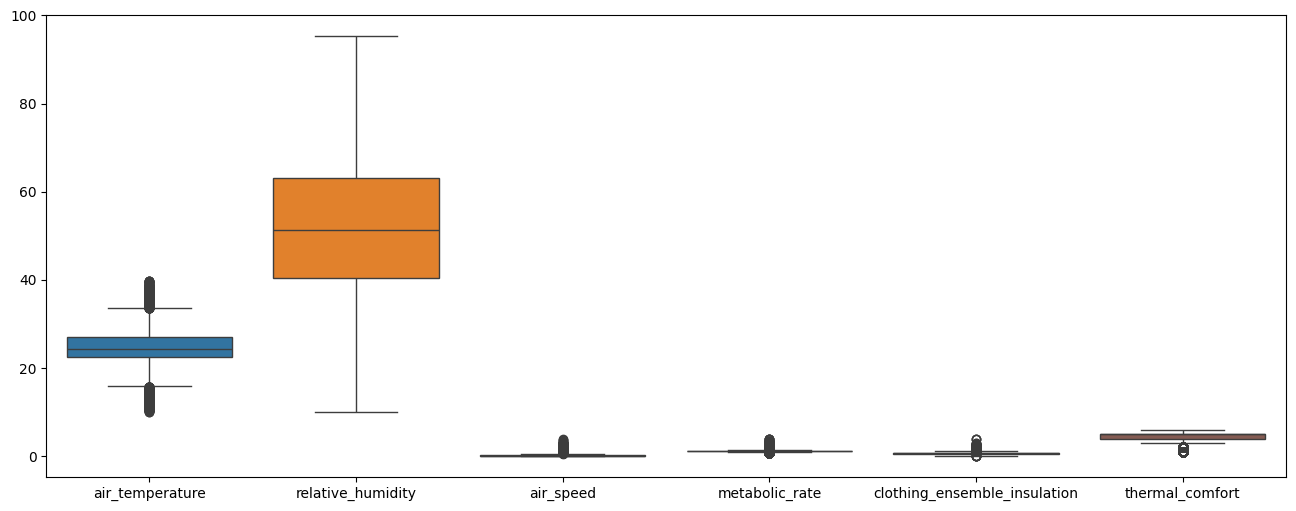

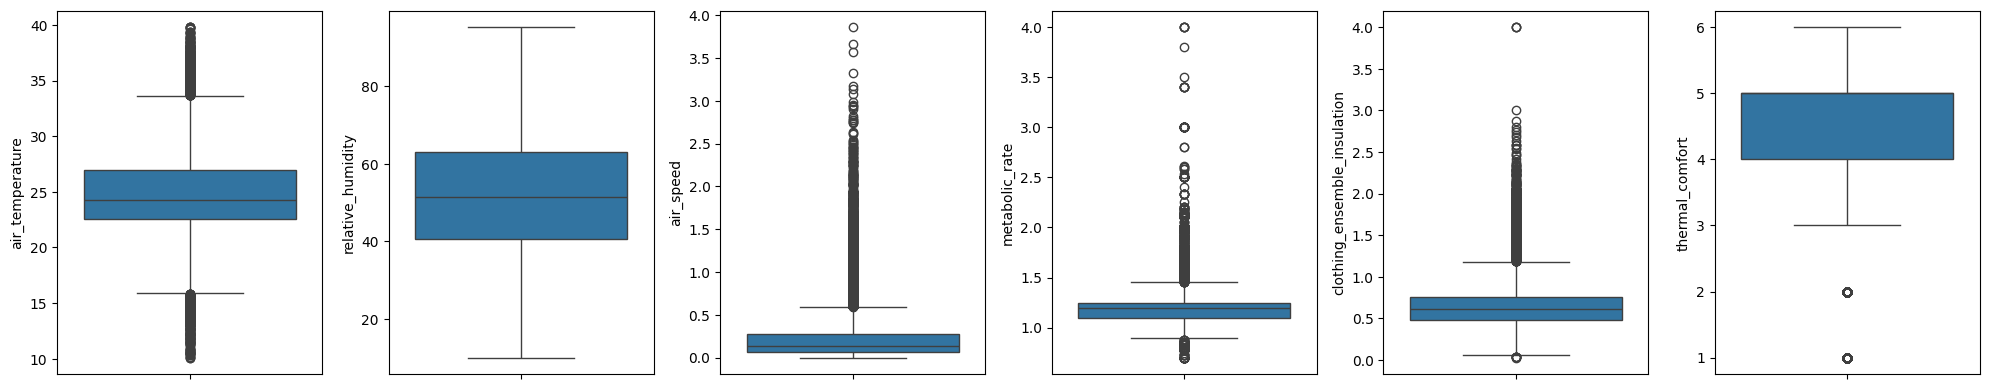

In [14]:
# boxplots

plt.figure(figsize=[16,6])
sns.boxplot(data=df_ml_clean)
plt.show()

fig, axes = plt.subplots(1, 6, figsize=(20, 4))
sns.boxplot(data=df_ml_clean["air_temperature"], ax=axes[0])
sns.boxplot(data=df_ml_clean["relative_humidity"], ax=axes[1])
sns.boxplot(data=df_ml_clean["air_speed"], ax=axes[2])
sns.boxplot(data=df_ml_clean["metabolic_rate"], ax=axes[3])
sns.boxplot(data=df_ml_clean["clothing_ensemble_insulation"], ax=axes[4])
sns.boxplot(data=df_ml_clean["thermal_comfort"], ax=axes[5])
plt.tight_layout()
plt.show()

# Alle Features, außer die Luftfeuchtigkeit haben viele Ausreißer, außer das Target "thermal_comfort"

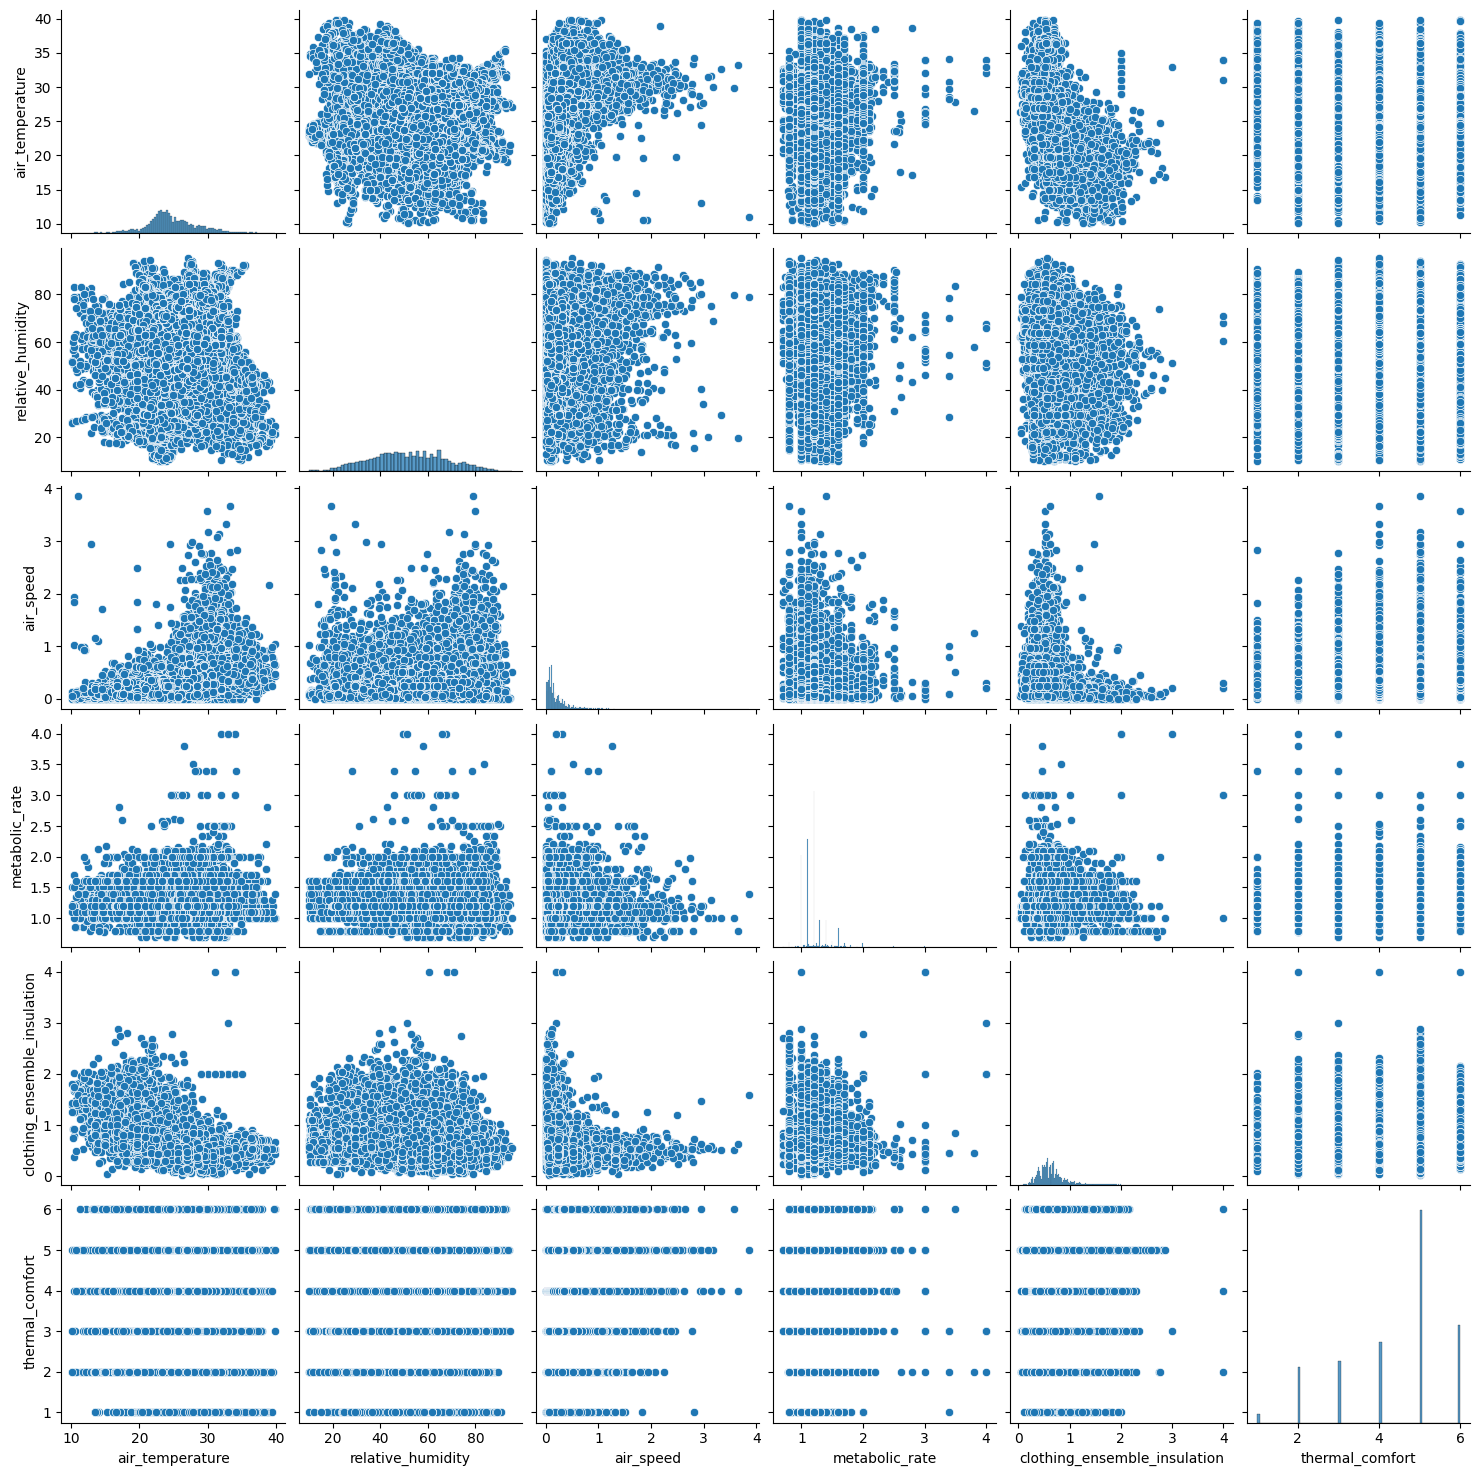

In [15]:
sns.pairplot(data=df_ml_clean)

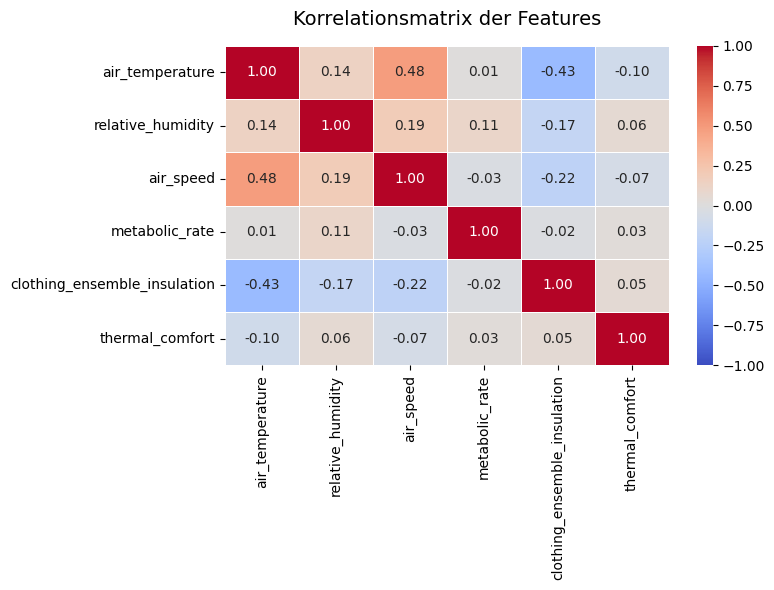

In [16]:
# Korrelationsmatrix

corr_matrix = df_ml_clean.corr()

# 2. Grafik (Heatmap) erstellen
plt.figure(figsize=(8, 6))

# sns.heatmap zeichnet das Diagramm
# annot=True schreibt die exakten Zahlenwerte in die Kästchen
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm',  # Blau = negative Korrelation, Rot = positive Korrelation
    fmt=".2f",        # Auf 2 Nachkommastellen runden
    linewidths=0.5,   # Dünne Trennlinien zwischen den Kästchen
    vmin=-1, vmax=1   # Die Farbskala exakt von -1 bis +1 begrenzen
)

plt.title('Korrelationsmatrix der Features', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Korrelation kann bei kNN und log. Regression zu Problemen der Genauigkeit führen. Bei Bäumen hat es weniger Einfluss auf die Genauigkeit aber auf die Featureimportance und somit auf die Interprätierbarkeit

### Bewertungsskala thermal_comfort:
- 0: Absolut ungemütlich / unerträglich (Very uncomfortable)
- 1: Ungemütlich (Uncomfortable)
- 2: Leicht ungemütlich (Slightly uncomfortable)
- 3: Akzeptabel / Neutral (Abit uncomfortable / acceptable)
- 4: Leicht gemütlich (Slightly comfortable)
- 5: Gemütlich (Comfortable)                                    >40% der Werte hier!
- 6: Sehr gemütlich / Perfekt (Very comfortable)

# Hauptproblem laut Manuskript (und aus eigener Erfahrung)

**Rauschminderung (menschliches Rauschen) und Klassen-Imbalance!!!**

TomekLinks zur Rauschminderung (intelligenter Datenfilter)
und
SMOTE für Klassen-Imbalance (fügt künstliche Datenpunkte hinzu)

beides führt dazu starkes Oversampling zu unterbinden.

# Notizen zu Fragen und Problemen bzgl. ML <div id="notizen"></div>
- Alle Features liegen als Zahlen vor (kein Feature Encoding notwendig), sind die Wertungen der Werte von Bedeutung?
- Balancing
- Einfluss Korrelation (nicht bei Bäumen) starke Korrelation, über 0.85 oder 0.9 gilt schon als extem hoch, 0.7 ist bereits stark! (=> Einfluss bei log. Regression und kNN) -> ggf. Features herauswerfern, Alternative wäre eine PCA (Hauptkomponentenanalyse), Dimensionsreduzierung
- Skalierung (nicht bei Bäumen), Log. Regression bevorzugt, StandardScaler, kNN eher den RobusScaler, RobustScaler eher gedacht bei Ausreißern (minMax und Standard da sehr anfällig), MinMaxScaler gut wenn Abstände zwischen den Werten von Bedeutung ist. MaxAbsScaler, PowerTransformer
- Estimatorwahl (Klassifikation => log. Regression, Decision Tree, kNN, Random Forest)
- Cross-validation für Train-Test-Set? (KFold, StratifiedKFold, ShuffleSplit, cross_val_score)
- Parameter des Algorthmus (GridSearchCV, RandomizedSearchCV )
- Overfitting (wie am besten zu prüfen?) (Beschneidung der Bäume?)
- Metriken für Auswertung
<br> <br>
- Haben die Feature eine relevante Rangordnung in den Werten die zu Problemen führe kann?
<br><br>
- Klassen des Targets (6 zuviel?)
- Auswahl der Features
<br><br>
- Korrelationen? Ausreißer???

### Auffälligkeiten / Besonderheiten bzgl. erster Aufgabe

- Es ist mit erheblichem label noise zu rechnen, da die Target das Resultat eines Fragebogens sind (Targets haben starkes Rauschen infolge Tagesform, Missverständnisse usw.). 
- Target hat 6 diskrete Werte
- Wert 5 im Target stark überpräsentiert (moderates Ungleichgewicht, Klasse 5 hat ca. 41%)
- Lufttemperatur, met und clo sehr rechtsschief (links mehr Werte)
- Die Feautures haben starke Ausreißer
- Wo kommt das Rauschen zwischen den Wertem bei thermal_comfort und thermal_sensation her, wo es im Fragebogen doch nur diskrete Werte gab?
- Ziel F1_macro_score bei 3 oder 6 Klassen: >0,5 solide Tendenz, >0,75 praxistauglich, >0,85 exzellent
<br><br>
- Anderes Target besser?
- Target von 6 auf zunächst 3 Werte reduzieren? (im Idealfall mit gleicher Verteilung), Möglich drei Targets zu filtern mit gleicher Verteilung???
- Andere classifier: SVC/SVM (support vector machines), SGD (stochastic gradient descent) oder andere?
- ggf. Reduzierung der Anzahl der Features, oder vielleicht sogar mehr (kNN hat zum Beispiel Probleme mit zu vielen Features!)
- Noch weitere Features: z.B. Cooling Type usw. oder auch !age!
<br><br>
- ggf. aus 6 Kategorien des Targets 5 machen und jeweils ca. 3000 Samples ziehen (200 von Klassen 1 in 2) => 15.000 Datensätze, statt knapp 27.000 dafür gleichverteilt (Alternativ 3 Kategorien mit je ca. 9000 Datensätzen)

-------------------------

Betrachtung im Trainset mit 6 Klassen (alle 320 Werte) fürt zu maximalem F1 Score von 0.33 => Unbalancing war voher nicht das große Problem!<br>
Mögliche andere Punkte für schlechten Score
- zu starke Überlappung der Klassen (Data Overlap)
- Weak Features (fehlende Vorhersagekraft)
- falsche Skalierung oder Vorverarbeitung -- sollte nicht der Fall sein
- Label Noise (garbage in, garbage out) - Problem Ausreißer oder Fehler in Targets, zuviel Rauschen was die richtigen Werte überdeckt -- Wahrscheinlich das größte Problem!!!
- Modellkomplexität passt nicht zur Datenstruktur

-------------------------------

## zu untersuchen!
- erste Ergebnisse sehr schlecht, wahrscheinlich wegen sehr starkem unbalancing des Target
- alles wird als Klasse 5 erkannt und dadurch dass das >40% der Werte ausmacht liegt die nichtssagende Accuracy bei knapp 50%
- der relavte F1-Score, wahrscheinlich der Macro Wert, liegt derzeit bei 0,31 und ist somit unzureichend
- Wieso reagiert Random Forest so unterschiedlich zu den anderen Modellen? Alle anderen klassifizieren 5 zu oft, Random Forest klassifiziert 5 oft als 3!
<br><br>
- Thermal comfort als Target rechtsschief!!! (41% der Werte liegen bei 5.0)
- eine schiefe Zielvariabhle (Klassen-Imbalance) führt dazu, dass Modelle die Majoritätklasse bevorzugen und die Minderheitenklasse ignorieren.
- => acc nicht die entscheidende Metrik, Precision, Recall und F1-Score verwednen oder ROC-AUC (Precisio-Recall Curve PR-AUC) - oder balanced accuracy_score
- => Modellgewichte anpassen (class_weights=balanced setzen bei random forest und log. Regression!!!)
- => Resampling der Daten mit Hilfe der imbalanced-learn Bibliothek (SMOTE)
<br><br>
- Vergleich F1-Score Trainingsset im Vergleich zum Testset (Overfitting-Check). Bisheriger Check nur auf die Vorhersagen! => Vergleich mit y_train/y_pred_train (großer Unterschied zwischen den Genauigkeiten deutet auf Overfitting hin!) => ggf. pruning etc.
<br><br>
- Außerdem möglich das Target zu Logarithmieren (Bei Klassifikationen ist der "TransformedTargetRegressor" nicht möglich). Bäume kommen damit klar, hier aber nicht nur rechtsschief, sondern auch unbalanced!!!
    - predicted Werte müssen dann zurücktransformiert werden
<br><br>
- Was ist smote im Vergleich zu Class Weights??? (SMOTE (Synthetic Minority Over-sampling Technique) Resampling des Traindatensatzes: Hierbei werden künstlich Beispiele der seltenen Klasse erzeugt oder Beispiele der häufigen Klasse gelöscht, um das Gleichgewicht wiederherzustellen. Zum Bespiel durch Mittelwerte von anderen Datensätze der gleichen Klasse. Die seltenen Klassen werden dadurch künstlich vergrößert)
    - Smote wird in einer Pipeline verwendet wie andere Transformer
- Categorical Cross-Entropy - logistischer Verlust (Cross-Entropy / Log Loss) gegen Ausreißer im Target

--------------------------------

## Problem label noise (Modell versucht verrauschte Fehlentscheidungen stur auswendig zu lernen)

Strategien auf Datenebene (Das Rauschen filtern)

1. Aggregation (Falls mehrere Fragen dasselbe messen)Stammt Ihr Target aus einer einzelnen Frage, ist das Rauschen maximal. Besteht das Target aus einem Score mehrerer Fragen (z. B. 5 Fragen zur Lebenszufriedenheit), mitteln Sie diese. Durch die Aggregation heben sich zufällige Ausreißer mathematisch gegenseitig auf.

2. Robustes Binning (Zurück zu Kategorien)Wenn Ihr Target ein kontinuierlicher Score (z. B. 0 bis 100) mit starkem Rauschen ist, wandeln Sie ihn in grobe Klassen um (z. B. Niedrig, Mittel, Hoch). Kleine, verrauschte Schwankungen (ob jemand eine 62 oder 65 angekreuzt hat) gehen dadurch im Gruppenmittel auf und verwirren das Modell nicht mehr.

Strategien auf Modellebene (Resistenz aufbauen)

Wenn Sie das Rauschen im Target belassen müssen, wählen Sie Algorithmen und Einstellungen, die "fehlertolerant" sind:<br><br>
1. Starke Regularisierung (**Weniger Overfitting**)<br><br>
Ein komplexes Modell versucht, jedes verrauschte Detail im Target perfekt auswendig zu lernen (Overfitting).
 - Lösung: Nutzen Sie starke Regularisierung. Bei baumbasierten Modellen (Random Forest, XGBoost) begrenzen Sie die Baumtiefe (max_depth=3 oder 4). Das zwingt das Modell, nur die großen, echten Trends der Features zu lernen und das feine Rauschen im Target zu ignorieren.<br><br>
2. Robuste Loss-Funktionen (Bei Regression)<br><br>
Falls es sich um eine Regression handelt, nutzen Sie statt dem Standard-MSE (Mean Squared Error) den Huber-Loss oder MAE (Mean Absolute Error). Der MSE bestraft große Abweichungen quadratisch. Ein verrauschter Extremwert im Fragebogen würde das gesamte Modell verzerren. MAE und Huber-Loss stecken solche "Fehlentscheidungen" der Probanden locker weg.<br><br>
3. Logistischer Verlust mit "Label Smoothing" (Bei Klassifikation)<br><br>
Wenn Ihr Target eine verrauschte Klassifikation ist, neigen Modelle dazu, sich bei Fehlern extrem stark zu bestrafen. **Label Smoothing** (verfügbar in vielen Deep-Learning-Frameworks und modernen Boosting-Algorithmen) lockert die harten Labels (0 und 1) mathematisch auf (z. B. zu 0.05 und 0.95). Das Modell wird nicht mehr "bestraft", wenn es ein verrauschtes Label nicht perfekt trifft.




Möglicherweise ist es besser trotz der vorhandenen Klassen in diesem Fall eine Regression zu verwenden. Das Ergebnis sind dann keine diskreten Werte mehr, aber die lassen sich auf diskrete Werte runden.

### TomekSmote gegen Label Noise (nicht SMOTETomek)

- SMOTETomek ist eine übliche Methode bei Imbalance im Target, hier ist der Anwendungsfall aber anders. Die Daten basieren auf Umfragen und haben dadurch bereits zu Begiin ein starkes "label noise". Zuerst Punkte in den Grenzbereichen der Klassen zuerzeugen wäre schlecht
- TomekSmote: 
    - Erst über TomekLink einen Filter erstellen, der Punkte in der Grenzregion zwischen zwei Klassen filter, bzw. in der Standardeinstellung bei sehr eng nebeneinanderliegenden Punkten den Punkt der Klasse mit mehr Werten löscht, um saubere Abgrenzen zu schaffen.
    - Danach über SMOTE die Targetklassen mit weniger Werten auffüllen, damit das Inbalance beseitigt wird.
- Für SMOTETomek gibt es eine fertig Methode: SMOTETomek(sampling_strategy='auto', random_state=42)

## Metriken für Klassifizierungen

- Accuracy: Genauigkeit (Nur sinnvoll bei balancierten Datensätze - Target mit gleicher Anzahl Klassen)Die Accuracy misst den Anteil aller korrekt klassifizierten Fälle an der Gesamtzahl der Fälle.) $$Accuracy = \frac{\text{True Positive} + \text{True Negative}}{\text{Gesamtanzahl}}$$
<br>
- Precision (macro, weighted): Präzision (Die Precision gibt an, wie viele der als positiv vorhergesagten Fälle tatsächlich positiv sind. Sie fokussiert sich auf die Vermeidung von Fehlalarmen (Falsch-Positive).) $$Precision = \frac{\text{True Positive}}{\text{True Positive} + \text{False Positive}}$$
<br>
- Recall (macro, weighted): Trefferquote (Der Recall gibt an, wie viele der tatsächlich positiven Fälle das Modell erkannt hat. Er fokussiert sich auf das Vermeiden von übersehenen Fällen (Falsch-Negative).)$$Recall = \frac{\text{True Positive}}{\text{True Positive} + \text{False Negative}}$$
<br>
- F1 Score: harmonische Mittel (Ausreißer werden mehr bestraft als bei artithm. Mittel) aus Precision (Präzision) und Recall (Trefferquote). Er fasst beide Werte in einer einzigen Kennzahl zusammen und ist besonders nützlich bei unbalancierten Datensätzen. $$F1\text{-Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$
    - Allgemein bei mehr als 2 Klassen im Target
        - macro average: (hier vermeintlich wichtige Metrik) Konzept: Jede Klasse trägt den gleichen Anteil zum Endergebnis bei. Performance des Algortihmus für alle Klassen gleichwichtig. $$\text{Macro Average} = \frac{\text{Metrik}_{\text{Klasse A}} + \text{Metrik}_{\text{Klasse B}} + \text{Metrik}_{\text{Klasse C}}}{3}$$
        - weighted average: (Der realisitische - jedoch bei unbalancierten Daten täuschen und ist riskant) Konzept: Klassen mit vielen Beispielen haben einen größeren Einfluss auf das Gesamtergebnis als seltene Klassen. $$\text{Weighted Average} = \frac{(\text{Metrik}_A \cdot \text{Anzahl}_A) + (\text{Metrik}_B \cdot \text{Anzahl}_B) + \dots}{\text{Gesamtanzahl}}$$

# logistische Regression

Es gibt 26 unterschiedliche Werte in thermal_comfort, oder? zumindest in der Uhrsprungs csv!!!
1/25 = 0.04

y hat nur 6 unterschiedliche Werte!!! Das kommt durch das dropna!!!
1/6 = 0.16

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import f1_score

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, FunctionTransformer, StandardScaler, RobustScaler

Prozentuale Werteverteilung: 
 thermal_comfort
5.0    41.127356
6.0    18.936470
4.0    15.626392
3.0    11.978626
2.0    10.735491
1.0     1.595666
Name: proportion, dtype: float64
Absolute Werteverteilung: 
 thermal_comfort
5.0    11083
6.0     5103
4.0     4211
3.0     3228
2.0     2893
1.0      430
Name: count, dtype: int64


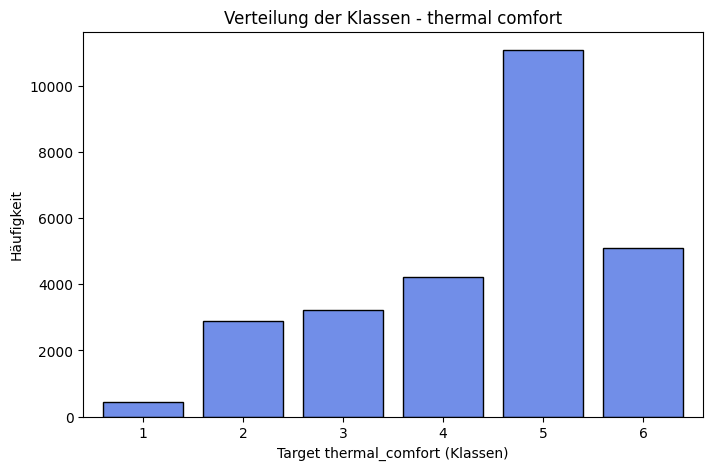

In [30]:
y = df_ml_clean['thermal_comfort']
X = df_ml_clean.drop(columns=['thermal_comfort'])

#print(type(y))

# Runden der Werte für y, um die Klassen zu reduzieren, sonst 17 Klassen, mit zum Teil nur 1 Wert!
#y = y.round(decimals=0)
y = np.floor(y + 0.5)

# y.unique()
#print(f"Werteverteilung Target thermal_comfort nach Runden auf ganze Werte{y.value_counts()}")
print(f"Prozentuale Werteverteilung: \n {y.value_counts(normalize=True) * 100}")
print(f"Absolute Werteverteilung: \n {y.value_counts()}")

#sns.histplot(data=y)
# Histplot mit Abstand (shrink) und zentrierten Balken (discrete)
plt.figure(figsize=(8, 5))
unique_classes = np.sort(y.unique())

# 'shrink=0.8' sorgt für den gewünschten Abstand zwischen den Balken
sns.histplot(x=y, discrete=True, shrink=0.8, color='royalblue', edgecolor='black')

# Die Achsenbeschriftungen exakt unter die Balken setzen
plt.xticks(unique_classes)
plt.xlim(unique_classes.min() - 0.6, unique_classes.max() + 0.6)

plt.xlabel("Target thermal_comfort (Klassen)")
plt.ylabel("Häufigkeit")
plt.title("Verteilung der Klassen - thermal comfort")
plt.show()



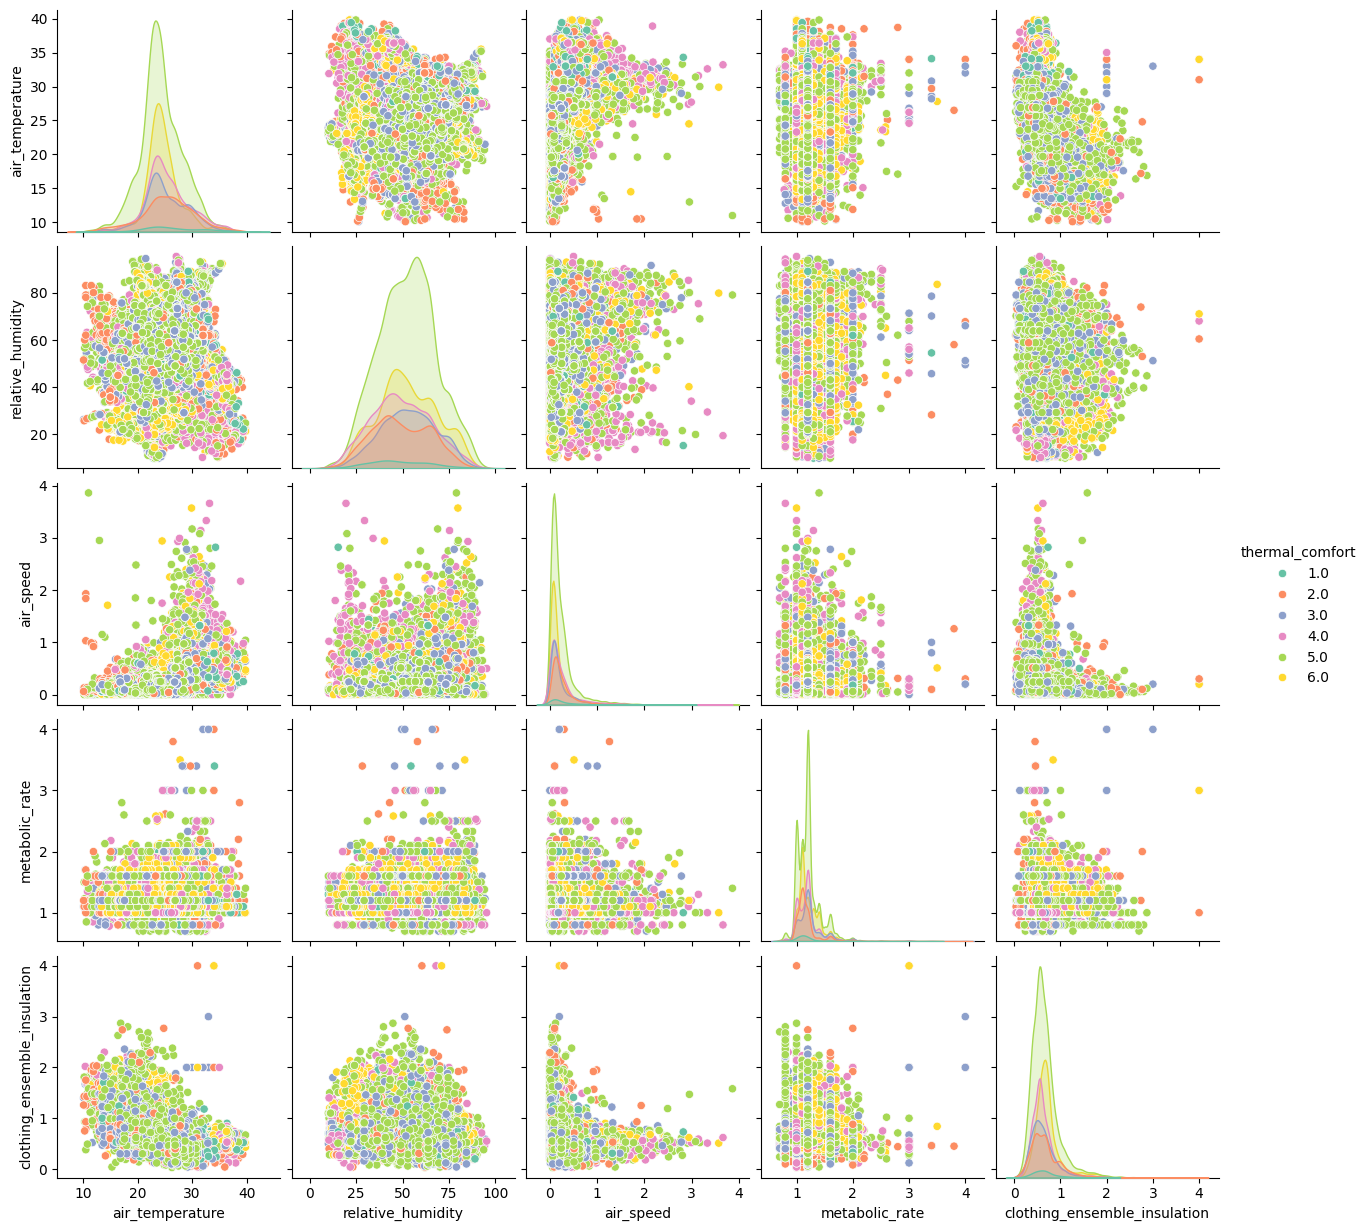

In [19]:
df_temp = df_ml_clean.copy()
#df_temp['thermal_comfort'] = df_temp['thermal_comfort'].round(decimals=0)
df_temp['thermal_comfort'] = np.floor(df_temp['thermal_comfort'] + 0.5)
sns.pairplot(data=df_temp, hue='thermal_comfort', palette='Set2')
del df_temp

Es sind mit den sechs Klassen des thermal_comfort optisch keine klaren Cluster zu erkennen.

In [20]:
df_ml_clean.describe()

,air_temperature,relative_humidity,air_speed,metabolic_rate,clothing_ensemble_insulation,thermal_comfort
count,26948.000000,26948.000000,26948.000000,26948.000000,26948.000000,26948.000000
mean,24.816549,51.610402,0.234099,1.205695,0.659131,4.407637
std,4.053475,15.651587,0.300596,0.215388,0.299897,1.302092
min,10.100000,10.000000,0.000000,0.700000,0.030000,1.000000
25%,22.560000,40.500000,0.070000,1.100000,0.480000,4.000000
50%,24.300000,51.400000,0.130000,1.200000,0.610000,5.000000
75%,27.000000,63.000000,0.280000,1.241468,0.760000,5.000000
max,39.800000,95.300000,3.860000,4.000000,4.000000,6.000000


## ! Bei Log. Regression und kNN Skalierung wichtig. Bei Bäumen nicht!

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratify für unbalancing, jedoch keine großen Unterschiede

In [22]:
y_test.value_counts()

thermal_comfort
5.0    2217
6.0    1021
4.0     842
3.0     646
2.0     578
1.0      86
Name: count, dtype: int64

In [23]:
from sklearn.linear_model import LogisticRegression

schiefe_features = ['air_speed', 'metabolic_rate', 'clothing_ensemble_insulation']
normale_features = ['air_temperature', 'relative_humidity']


##################################################################################################
# definieren der schiefen Features für logarithmus
#schiefe_transformer = Pipeline(steps=[
#    ('log1p', FunctionTransformer(np.log1p)),   # natürlicher Log zu schwach
#    ('scaler', StandardScaler())
#])

# log. Regression bevorzugt eher StandardScaler
# die vielen Ausreißer sprechen eher für einen RobustScaler

# StandardScaler für schiefe Features
schiefe_transformer = Pipeline(steps=[
    # Sucht automatisch die beste mathematische Funktion (z.B. Box-Cox oder Yeo-Johnson)
    ('power_transform', PowerTransformer(method='yeo-johnson')) 
])

# Alternativ mit Robust, Scaler statt StandardScaler
#schiefe_pipeline = Pipeline(steps=[
#    # Wichtig: standardize=False schaltet das automatische 'StandardScaler'-Verhalten aus
#    ('power', PowerTransformer(method='yeo-johnson', standardize=False)), 
#    # Jetzt skaliert der RobustScaler die transformierten Daten ausreißersicher
#    ('robust_scale', RobustScaler()) 
#])




# Alternativen zum StandardScaler, RobustScaler (bei Ausreißern), MinMaxScaler (gut für neuronale Netze), MaxAbsScaler (für dünnbesetzte Daten)
# RobustScaler oder StandardScaler hier
preprocessor = ColumnTransformer(
    transformers=[
        ('schief', schiefe_transformer, schiefe_features),
        ('normal', StandardScaler(), normale_features)  # Normale Spalten werden nur skaliert - hier mit StandardScaler
        #('normal', RobustScaler(), normale_features) # Alternative zu StandardScaler der RobustScaler - Nachteile bei logReg, man verliert Infos zu Ausreißern auch wenn er dafür besser ist, hohe Anfälligkeit bei wenig Daten
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=100, class_weight='balanced', penalty='l2')) #    penalty quasi keinen Einfluss
])
##################################################################################################

###########################################################################
# allgemeine Pipeline ohne log
#pipeline = Pipeline([
#    ('scaler', StandardScaler()),
#    ('classifier', LogisticRegression(max_iter=100))
#])
###########################################################################

# 4. Pipeline trainieren (skaliert X_train intern und trainiert das Modell)
pipeline.fit(X_train, y_train)

# 5. Vorhersagen treffen (skaliert X_test intern mit den Werten aus dem Training)
y_pred = pipeline.predict(X_test)

# 6. Bewertung
print("Logistische Regression")
accuracy = accuracy_score(y_test, y_pred)
print(f"Genauigkeit mit Pipeline: {accuracy:.2f}")
#score = f1_score(y_test, y_pred)
#print(f"F1-Score: {score:.2f}")
print("\nDetaillierter Klassifikationsbericht:")
print(classification_report(y_test, y_pred, zero_division=0))

# Entscheidend f1-Score unten macro und weighted avg
# Kurz gesagt: macro avg behandelt alle Klassen gleich, während weighted avg große Klassen bevorzugt.
# accuracy hier irreführend, da stark unbalancierte Klassen!!! acc = (Richtig Positiv + Richtig Negativ) / Alle Datenpunkte
# F1-Score (Das harmonische Mittel): Der F1-Score wird nur dann hoch, wenn sowohl Precision als auch Recall hoch sind. Er zwingt das Modell, bei der Zielklasse präzise zu sein und möglichst viele Fälle davon zu finden. Einsatz: Perfekt für unbalancierte Daten, weil es die Minderheitsklasse genauso stark wertschätzt wie die Mehrheitsklasse. Wenn dein Modell die seltene Klasse komplett verpatzt, zieht das den macro avg drastisch nach unten.
# Macro Average (macro avg): Hier wird der F1-Score für jede Klasse einzeln berechnet und anschließend der einfache, ungewichtete Durchschnitt gebildet. Logik: Jede Klasse zählt exakt gleich viel für das Endergebnis – völlig egal, ob eine Klasse 1.000 Datenpunkte hat oder nur 5.
# Weighted Average (weighted avg)Hier wird der F1-Score jeder Klasse mit der Anzahl ihrer Datenpunkte (Support) multipliziert, bevor der Durchschnitt gebildet wird. Logik: Große Klassen haben einen riesigen Einfluss auf das Endergebnis. Kleine Klassen gehen fast unter. Einsatz: Nützlich, wenn das echte Mengenverhältnis der Klassen in deiner Bewertung widergespiegelt werden soll. Bei stark unbalancierten Daten kann dieser Wert jedoch täuschen.

Logistische Regression
Genauigkeit mit Pipeline: 0.24

Detaillierter Klassifikationsbericht:
              precision    recall  f1-score   support

         1.0       0.04      0.31      0.07        86
         2.0       0.15      0.26      0.19       578
         3.0       0.19      0.25      0.22       646
         4.0       0.18      0.11      0.14       842
         5.0       0.51      0.20      0.28      2217
         6.0       0.30      0.44      0.36      1021

    accuracy                           0.24      5390
   macro avg       0.23      0.26      0.21      5390
weighted avg       0.34      0.24      0.25      5390



c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


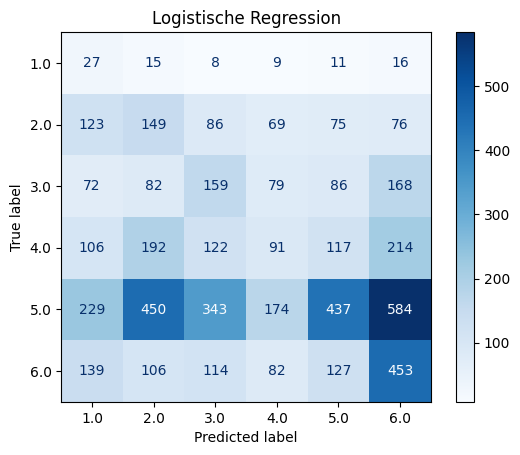

In [24]:
# confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Logistische Regression")
plt.show()

Großer Einfluss durch class_weight='balanced', mit balanced (also gegen das Klassenungleichgewicht), wird der F1-Score besser, ohne wird Klasse 5 besser getroffen, aber fast nur noch Klasse 5

In [25]:
# Erster Test Auswirkung Logarithmierung
X_log=X.copy()
#X_log['air_speed_log'] = np.log1p(X_log['air_speed']) # natürlicher Logarithmus
#X_log['air_speed_log'] = np.log10(X_log['air_speed']) # Logarithmus auf Basis 10
#X_log['metabolic_rate'] = np.log10(X_log['metabolic_rate'])
#X_log['clothing_ensemble_insulation'] = np.log10(X_log['clothing_ensemble_insulation'])
#X_log

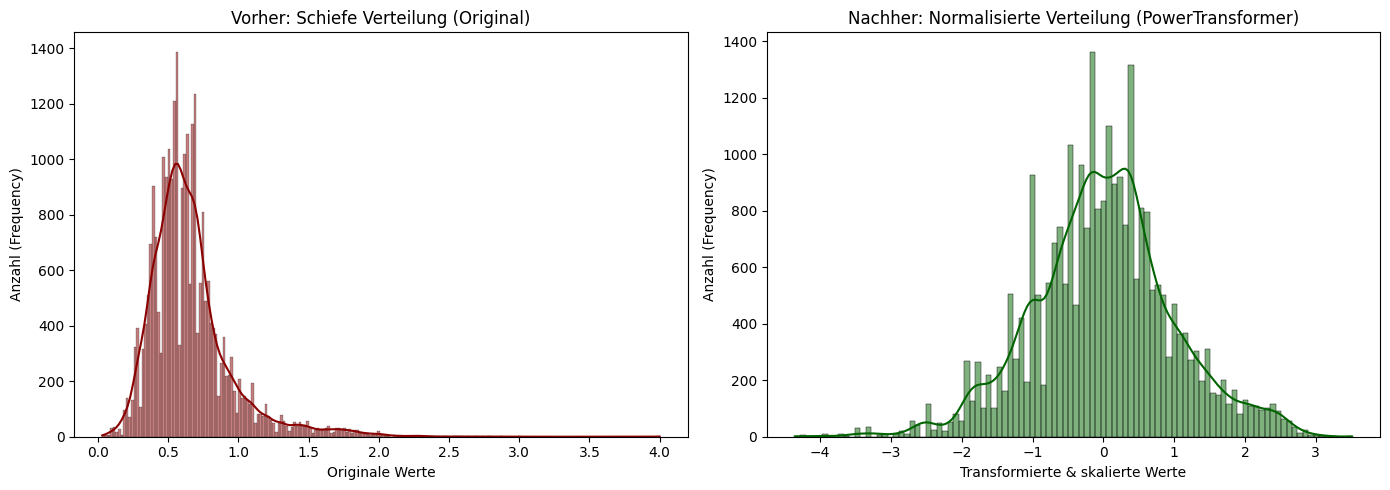

In [26]:
#import matplotlib.pyplot as plt
#import seaborn as sns
#from sklearn.preprocessing import PowerTransformer

# 1. PowerTransformer initialisieren und auf die schiefe Spalte anwenden
# Wichtig: Der Transformer erwartet ein 2D-Array, daher das Doppel-Bracket [['...']]
pt = PowerTransformer(method='yeo-johnson')
transformed_feature = pt.fit_transform(X[['clothing_ensemble_insulation']])
#transformed_feature = pt.fit_transform(X[['metabolic_rate']])


# 2. Plot-Fenster für den direkten Vergleich erstellen (1 Zeile, 2 Spalten)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Linker Plot: Vor der Transformation ---
sns.histplot(X['clothing_ensemble_insulation'], kde=True, ax=axes[0], color='darkred')
#sns.histplot(X['metabolic_rate'], kde=True, ax=axes[0], color='darkred')
axes[0].set_title('Vorher: Schiefe Verteilung (Original)')
axes[0].set_xlabel('Originale Werte')
axes[0].set_ylabel('Anzahl (Frequency)')

# --- Rechter Plot: Nach der Transformation ---
# transformed_feature ist ein NumPy-Array, wir flachen es mit .flatten() für Seaborn ab
sns.histplot(transformed_feature.flatten(), kde=True, ax=axes[1], color='darkgreen')
axes[1].set_title('Nachher: Normalisierte Verteilung (PowerTransformer)')
axes[1].set_xlabel('Transformierte & skalierte Werte')
axes[1].set_ylabel('Anzahl (Frequency)')

# Layout optimieren und Diagramm anzeigen
plt.tight_layout()
plt.show()


Skalierung war bei log. Regression ohne großen Einfluss

## Decision Tree

In [ ]:
# Decision Tree => kein Scaler notwendig

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#model = DecisionTreeClassifier(max_depth=14, random_state=42, class_weight='balanced') # 0.3 mit balanced, ohne 0.3 Score
model = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
#model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# 4. Vorhersagen treffen
y_pred = model.predict(X_test)

# 5. Modell bewerten
print("Decision Tree")
accuracy = accuracy_score(y_test, y_pred)
print(f"Genauigkeit (Accuracy): {accuracy:.2f}")
#score = f1_score(y_test, y_pred)
#print(f"F1-Score: {score:.2f}")
print("\nDetaillierter Klassifikationsbericht:")
print(classification_report(y_test, y_pred, zero_division=0))

# 6. Optional: Den Baum visuell darstellen
plt.figure(figsize=(80, 48))
plot_tree(model, filled=True, feature_names=X.columns, class_names=[str(c) for c in model.classes_])
plt.show()

In [ ]:
# confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Decision Tree")
plt.show()

Auch hier sehr großer Einfluss durch class_weight='balanced', ohne leicht besserer F1 Wert, es wird aber fast nur noch Klasse 5 getroffen, aber fast nur noch Klasse 5!!!

# kNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# Scaler hier sehr wichtig!!!

# eigentlich sollte der RobustScaler hier der beste sein

##################################################################################################
'''
#schiefe_transformer = Pipeline(steps=[
#    ('log1p', FunctionTransformer(np.log1p)),   # natürlicher Log zu schwach
#    ('scaler', StandardScaler())
#])

# StandardScaler für schiefe Features
schiefe_transformer = Pipeline(steps=[
    # Sucht automatisch die beste mathematische Funktion (z.B. Box-Cox oder Yeo-Johnson)
    ('power_transform', PowerTransformer(method='yeo-johnson')) 
])

#schiefe_pipeline = Pipeline(steps=[
#    # Wichtig: standardize=False schaltet das automatische 'StandardScaler'-Verhalten aus
#    ('power', PowerTransformer(method='yeo-johnson', standardize=False)), 
#    # Jetzt skaliert der RobustScaler die transformierten Daten ausreißersicher
#    ('robust_scale', RobustScaler()) 
#])

preprocessor = ColumnTransformer(
    transformers=[
        ('schief', schiefe_transformer, schiefe_features),  # features bei log.Regression definiert
        ('normal', StandardScaler(), normale_features)  # Normale Spalten werden nur skaliert - hier mit StandardScaler
        #('normal', RobustScaler(), normale_features) # Alternative zu StandardScaler der RobustScaler - Nachteile bei logReg, man verliert Infos zu Ausreißern auch wenn er dafür besser ist, hohe Anfälligkeit bei wenig Daten
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5, weights="distance"))
])
'''

##################################################################################################




# Split bleibt identisch
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# WICHTIG für kNN: Daten skalieren
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# kNN Classifier (weights="distance" hilft oft bei unbalancierten Daten)
model = KNeighborsClassifier(n_neighbors=8, weights="distance")
model.fit(X_train_scaled, y_train)

# Vorhersagen treffen (auf den skalierten Testdaten!)
y_pred = model.predict(X_test_scaled)
#y_pred = model.predict(X_test)

# Ohne Pipeline sogar besser und PowerTransformer sogar besser, dann 0,32 statt 0,3!

#pipeline.fit(X_train, y_train)
#y_pred = pipeline.predict(X_test)




# Modell bewerten
print("kNN")
accuracy = accuracy_score(y_test, y_pred)
print(f"Genauigkeit (Accuracy) - kNN: {accuracy:.2f}")
print("\nDetaillierter Klassifikationsbericht:")
print(classification_report(y_test, y_pred, zero_division=0))

#macro_f1 = f1_score(y_test, y_pred, average="macro")
#weighted_f1 = f1_score(y_test, y_pred, average="weighted")
#print(f"Einheitlicher F1-Score (Macro): {macro_f1:.2f}, (weighted):{weighted_f1:.2f}")

# Hinweis: kNN lässt sich nicht wie ein Baum visualisieren, 
# da es keine festen Regeln, sondern nur Nachbarschaftsbeziehungen lernt.


In [ ]:
# confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("kNN")
plt.show()

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# kein Scaler notwendig!

# Split bleibt identisch
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Random Forest Classifier (class_weight hilft bei unbalancierten Daten)
#model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, class_weight="balanced")
#model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, class_weight="balanced") # class_weight="balacened" für ungleiche Verteilung


#model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, class_weight="balanced", n_jobs=-1) # class_weight="balacened" für ungleiche Verteilung
# => Lücke (Gap) beim F1-Score: 0.34

model = RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=20, random_state=42, class_weight="balanced", n_jobs=-1)    # max_depth=5

model.fit(X_train, y_train)

# Vorhersagen treffen
y_pred = model.predict(X_test)

# Modell bewerten
print("Random Forest")
accuracy = accuracy_score(y_test, y_pred)
print(f"Genauigkeit (Accuracy) - Random Forest: {accuracy:.2f}")
print("\nDetaillierter Klassifikationsbericht:")
print(classification_report(y_test, y_pred, zero_division=0))

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

f1_train = f1_score(y_train, y_train_pred, average='macro')
f1_test = f1_score(y_test, y_test_pred, average='macro')

gap = f1_train - f1_test
print(f"f1_train: {f1_train}")
print(f"f1_test: {f1_test}")
print(f"Lücke (Gap) beim F1-Score: {gap:.2f}")


In [ ]:

# Visualisierung (Feature Importance statt einzelnem Baum, da es viele Bäume gibt)
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)
importances.plot(kind='bar', figsize=(10, 6))
plt.title("Feature Importances (Wichtigkeit der Merkmale)")
plt.show()

# in der Form sehr starkes Overfitting von >0,3 (siehe Vergleich der Varianten)

Feature importance ist nicht sehr aussagekräftig. Zeigt nur welches Feature für die Erstellung des Baums wichtig war.

In [ ]:
# confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Random Forest")
plt.show()

Wieso wird in dem Modell label 5 so oft falsch als 3 erkannt!!!

## Versuch SHAP-Analyse

Andere Reiehnfolge als die Feature Importance. SHAP ist deutlich mehr zu vertrauen!!! Feature Importance misst nur wie wichtig ein Feature beim Erstellen des Baumes war, nicht den wirklichen Einfluss, wie es bei SAHP der Fall ist. Feature importance ist sehr empfindlich auf Rauschen!

In [ ]:
import shap
import numpy as np

# 1. Explainer wie gewohnt erstellen
explainer = shap.TreeExplainer(model)

# 2. NEU: Direktes Aufrufen erzeugt das korrekte Explanation-Objekt
# (Berechnet die SHAP-Werte und behält Feature-Namen & Basiswerte)
shap_values_object = explainer(X_test)  # rechenintensiver Bereich  # initiert mit den Testdaten! mit den skalierten Daten, wenn sie so verwendet wurden! Also X_test_trasnsformed

In [ ]:
# 2. Umwandlung in das von SHAP erwartete Listen-Format für alle Klassen
# Extrahiert die Daten für jede der 6 Klassen separat in eine Liste
shap_all_classes = [shap_values_object.values[:, :, i] for i in range(len(model.classes_))]

# 3. Der komplette Gesamt-Plot
shap.summary_plot(
    shap_all_classes, 
    X_test, # hier Testdaten auch ggf. skaliert also X_test_transformed
    plot_type="bar", 
    class_names=model.classes_  # Benennt die Legende nach Ihren echten Klassen
)

In [ ]:
# 3. Globale Übersicht (funktioniert weiterhin mit dem Objekt)
# shap.summary_plot(shap_values_object, X_test)
#shap.summary_plot(shap_values_object[:, :, 0], X_test)  # globale Betrachtung

# Violinenplots für unterschiedliche Klassen
#print("Klasse 5, Index 4")
#shap.summary_plot(shap_values_object[:, :, 4], X_test)
#print("Klasse 6, Index 5")
#shap.summary_plot(shap_values_object[:, :, 5], X_test)  # globale Betrachtung

for i in range(len(model.classes_)):
    print(f"Klasse mit Index: {i}")
    shap.summary_plot(shap_values_object[:, :, i], X_test)  # globale Betrachtung

# 4. Erklärung der ersten Beobachtung (jetzt fehlerfrei)
# Bei Binär-Klassifikation / Regression:
# shap.plots.waterfall(shap_values_object[0])

'''
beobachtung = 0  # Die erste Zeile aus X_test
#ziel_klasse = 2  # Erklärung für die DRITTE Klasse Ihres Targets
ziel_klasse = 5  # Erklärung für die DRITTE Klasse Ihres Targets

shap.plots.waterfall(shap_values_object[beobachtung, :, ziel_klasse])
'''

In [ ]:
## 1. Explainer und SHAP-Werte erstellen
#explainer = shap.TreeExplainer(model)
#shap_values_object = explainer(X_test)

# 2. Parameter für die Analyse festlegen
#beobachtung_idx = 0  # Index der Zeile, die Sie erklären möchten
beobachtung_idx = 1  # Index der Zeile, die Sie erklären möchten

# 3. Die vorhergesagte Klasse für diese spezifische Zeile ermitteln
# model.predict() liefert das Label (z. B. "Klasse 3" oder Text)
vorhersage = model.predict(X_test.iloc[[beobachtung_idx]])[0]

# Falls Ihr Modell Klassenlabels (z.B. Strings) statt numerischer Indizes (0-5) nutzt,
# ermitteln wir hier den exakten numerischen Index der Klasse im Modell:
klasse_idx = np.where(model.classes_ == vorhersage)[0][0]

# 4. Textausgabe zur Kontrolle
print(f"Erklärung für Beobachtung {beobachtung_idx}")
print(f"Modell-Vorhersage: {vorhersage} (Klassen-Index im SHAP-Objekt: {klasse_idx})")

# 5. Waterfall-Plot exakt für die vorhergesagte Klasse aufrufen
shap.plots.waterfall(shap_values_object[beobachtung_idx, :, klasse_idx])    # Einzelvorhersage / Erklärung / Ein Datensatz wird erklärt
# Unten E[f(X)] ist der Durchschnitt, der Erwartungswert für diese Klasseals Durchschnitt über den gesamten Trainingsdatensatz
# Nach oben hin Stück für Stück Berechnung des finalen Ergebnis

# z.B. für Zeile mit Index 0: 0.672 ist Wahrscheinlichkeit für den Klassenwert

## Modell abspeichern

In [ ]:
import joblib

metrics = {
    "y_test" : y_test,
    "y_train" : y_train,
    "y_train_pred" : y_train_pred,
    "y_test_pred" : y_test_pred,
    "f1_train" : f1_train,
    "f1_test" : f1_test,
}

classification = {
    "model" : model,
    "metrics" : metrics,
    "explainer": explainer,
    "shap_values": shap_values_object,
}

# Speicherpfad und Dateiname definieren
modell_dateiname = 'klassifikations_modell_RandomForest_thermal_pref.joblib'

# Die komplette Pipeline (inklusive Vorverarbeitung und Polynomen) speichern
#joblib.dump(classification, modell_dateiname) # ca. 48mb
joblib.dump(classification, modell_dateiname, compress=3) # ca. 28mb

print(f"✅ Das Modell wurde erfolgreich unter '{modell_dateiname}' gespeichert!")


# 5 Modelle Skript <div id="basismodell"></div>

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split

# 1. Split (mit Stratify für unbalancierte Daten)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Spaltennamen definieren
schiefe_features = ['air_speed', 'metabolic_rate', 'clothing_ensemble_insulation']
normale_features = ['air_temperature', 'relative_humidity']

# 2. Preprocessor bauen
preprocessor = ColumnTransformer(
    transformers=[
        # PowerTransformer normalisiert UND skaliert die schiefen Spalten automatisch
        ('schief', PowerTransformer(method='yeo-johnson'), schiefe_features),
        # Normale Features brauchen nur den StandardScaler
        ('normal', StandardScaler(), normale_features)
        #('normal', RobustScaler(), normale_features)    #   normalerweise der bessere Scaler für kNN hier aber schlechter
    ]
)

#preprocessor.set_output(transform="pandas")

# 3. Modelle in einer Schleife testen
modelle = {
    "Logistische Regression": LogisticRegression(max_iter=100, class_weight='balanced', penalty='l2', random_state=42),
    # Bäume stört der PowerTransformer nicht, sie funktionieren damit genauso gut
    "Decision Tree": DecisionTreeClassifier(max_depth=11, random_state=42, class_weight='balanced'),
    "kNN": KNeighborsClassifier(n_neighbors=50, weights="uniform"),
    #"Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, class_weight="balanced", n_jobs=-1),    # max_depth=5 # F1 Score max mit 0,36
    #"Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, class_weight="balanced", n_jobs=-1),    # max_depth=5
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=20, random_state=42, class_weight="balanced", n_jobs=-1),    # max_depth=5
    #"HistGradientBoosting": HistGradientBoostingClassifier(max_iter=400, learning_rate=0.08, max_depth=12, max_leaf_nodes=127, min_samples_leaf=5, class_weight='balanced', random_state=42) #
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=500, learning_rate=0.05, max_leaf_nodes=45, min_samples_leaf=15, early_stopping=True, n_iter_no_change=15, class_weight='balanced', random_state=42) #
}

# overfitting bei Bäumen von 0.1-0.15 sehr praktikabel, bei kNN sollten es maximal eher 0.03 sein

trainierte_pipelines = {}


for name, model in modelle.items():
    # Pipeline für das aktuelle Modell erstellen
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren (Transformer lernt NUR von X_train)
    pipeline.fit(X_train, y_train)
    
    # Pipeline in unserem Dictionary für spätere Auswertungen sichern
    trainierte_pipelines[name] = pipeline

    # Vorhersagen (Transformer wendet gelerntes Wissen auf X_test an)
    y_pred = pipeline.predict(X_test)
    
    print(f"\n===== {name} =====")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred, zero_division=0))

    #############################################
    # Automatische Interpretation der Lücke (Gap)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    f1_train = f1_score(y_train, y_train_pred, average='macro')
    f1_test = f1_score(y_test, y_test_pred, average='macro')

    gap = f1_train - f1_test
    print(f"f1_train: {f1_train}")
    print(f"f1_test: {f1_test}")
    print(f"Lücke (Gap) beim F1-Score: {gap:.2f}")

    if gap > 0.15:
        print("⚠️ Warnung: Starkes Overfitting! Das Modell schneidet im Training deutlich besser ab als auf den Testdaten.")
    elif gap > 0.05:
        print("💡 Hinweis: Leichtes Overfitting. Das ist bei Random Forests oft normal, behalten Sie es aber im Auge.")
    else:
        print("✅ Optimal: Kein Overfitting. Das Modell generalisiert hervorragend auf neuen Daten.")
    print("=========================\n")

    #############################################

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

#X_train, X_test, y_train, y_test = train_test_split(
#    X, y, test_size=0.2, random_state=42, stratify=y
#)

# Dictionary, um die Ergebnisse für die Grafik zu speichern
macro_f1_results = {}

# Die Schleife trainiert die Modelle und speichert den Macro F1-Score
for name, model in modelle.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren & Vorhersagen
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Einheitlichen Macro F1-Score berechnen und speichern
    score = f1_score(y_test, y_pred, average='macro')
    macro_f1_results[name] = score

# --- Grafik erstellen ---
plt.figure(figsize=(10, 6))

# Farben für die einzelnen Balken definieren
farben = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

# Balkendiagramm zeichnen
bars = plt.bar(macro_f1_results.keys(), macro_f1_results.values(), color=farben, edgecolor='black', width=0.6)

# Werte oben auf die Balken schreiben
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Diagramm-Details anpassen
plt.title('Modellvergleich: Macro F1-Score (Basismodell - thermal comfort)', fontsize=14, pad=15)
plt.ylabel('Macro F1-Score', fontsize=12)
plt.ylim(0, 1.1)  # Platz für die Textlabels oben lassen
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Grafik anzeigen
plt.tight_layout()
plt.show()

Weitere Betrachtung erstmal nicht vorgenommen, da nicht zu erwarten ist, dass die F1-Scores sich durch andere Hyperparameter deutlich verbessern lassen!

Evtl. versuchen über imbalanced-learn etwas zu verbessern, um das Problem der starken imbalance des Targets auszugleichen!!!

Ggf. versuchen die Zeilen so zu filtern, dass die Ergebnisse gleich verteilt sind, was kommt dann raus?

# Reduzierung der Analyse auf einen deutlich kleineren aber bzgl. des targets gleichverteilten Datensatzes <div id="modell_klein_gleichverteilt"></div>

In [ ]:
df_balanciert = df_ml_clean.copy()
#df_balanciert['thermal_comfort'] = df_balanciert['thermal_comfort'].round(decimals=0)
df_balanciert['thermal_comfort'] = np.floor(df_balanciert['thermal_comfort'] + 0.5)
#df_balanciert
df_balanciert = df_balanciert.groupby('thermal_comfort').sample(n=400, random_state=42) # 6*400 Datensätze

In [ ]:
df_balanciert # nur noch 2400

In [ ]:
sns.pairplot(data=df_balanciert, hue="thermal_comfort", palette="Set2")
plt.show

In [ ]:
# 1. Split (mit Stratify für unbalancierte Daten)

y = df_balanciert['thermal_comfort']
X = df_balanciert.drop(columns=['thermal_comfort'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Spaltennamen definieren
schiefe_features = ['air_speed', 'metabolic_rate', 'clothing_ensemble_insulation']
normale_features = ['air_temperature', 'relative_humidity']

# 2. Preprocessor bauen
preprocessor = ColumnTransformer(
    transformers=[
        # PowerTransformer normalisiert UND skaliert die schiefen Spalten automatisch
        ('schief', PowerTransformer(method='yeo-johnson'), schiefe_features),
        # Normale Features brauchen nur den StandardScaler
        ('normal', StandardScaler(), normale_features)
    ]
)

# 3. Modelle in einer Schleife testen
modelle = {
    "Logistische Regression": LogisticRegression(max_iter=100, class_weight='balanced', penalty='l2', random_state=42),
    # Bäume stört der PowerTransformer nicht, sie funktionieren damit genauso gut
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'),
    "kNN": KNeighborsClassifier(n_neighbors=60, weights="uniform"),
    #"Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight="balanced", n_jobs=-1), # max_depth=5
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=20, random_state=42, class_weight="balanced", n_jobs=-1), # max_depth=5
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=500, learning_rate=0.03, max_depth=5, max_leaf_nodes=15, min_samples_leaf=100, l2_regularization=30.0, early_stopping=True, n_iter_no_change=15, validation_fraction=0.1, class_weight='balanced', random_state=42) #
    #"HistGradientBoosting": HistGradientBoostingClassifier(max_iter=500, learning_rate=0.05, max_leaf_nodes=45, min_samples_leaf=15, early_stopping=True, n_iter_no_change=15, class_weight='balanced', random_state=42) #
}

trainierte_pipelines = {}

for name, model in modelle.items():
    # Pipeline für das aktuelle Modell erstellen
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren (Transformer lernt NUR von X_train)
    pipeline.fit(X_train, y_train)
    
    # Pipeline in unserem Dictionary für spätere Auswertungen sichern
    trainierte_pipelines[name] = pipeline

    # Vorhersagen (Transformer wendet gelerntes Wissen auf X_test an)
    y_pred = pipeline.predict(X_test)
    
    print(f"\n===== {name} =====")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred))

    #############################################
    # Automatische Interpretation der Lücke (Gap)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    f1_train = f1_score(y_train, y_train_pred, average='macro')
    f1_test = f1_score(y_test, y_test_pred, average='macro')

    gap = f1_train - f1_test
    print(f"f1_train: {f1_train}")
    print(f"f1_test: {f1_test}")
    print(f"Lücke (Gap) beim F1-Score: {gap:.2f}")

    if gap > 0.15:
        print("⚠️ Warnung: Starkes Overfitting! Das Modell schneidet im Training deutlich besser ab als auf den Testdaten.")
    elif gap > 0.05:
        print("💡 Hinweis: Leichtes Overfitting. Das ist bei Random Forests oft normal, behalten Sie es aber im Auge.")
    else:
        print("✅ Optimal: Kein Overfitting. Das Modell generalisiert hervorragend auf neuen Daten.")
    print("=========================\n")

    #############################################

In [ ]:
# Dictionary, um die Ergebnisse für die Grafik zu speichern
macro_f1_results = {}

# Die Schleife trainiert die Modelle und speichert den Macro F1-Score
for name, model in modelle.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren & Vorhersagen
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Einheitlichen Macro F1-Score berechnen und speichern
    score = f1_score(y_test, y_pred, average='macro')
    macro_f1_results[name] = score

# --- Grafik erstellen ---
plt.figure(figsize=(10, 6))

# Farben für die einzelnen Balken definieren
farben = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

# Balkendiagramm zeichnen
bars = plt.bar(macro_f1_results.keys(), macro_f1_results.values(), color=farben, edgecolor='black', width=0.6)

# Werte oben auf die Balken schreiben
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Diagramm-Details anpassen
plt.title('Modellvergleich: (Datensatz stark reduziert für gleichverteilte Targetklassen)', fontsize=14, pad=15)
plt.ylabel('Macro F1-Score', fontsize=12)
plt.ylim(0, 1.1)  # Platz für die Textlabels oben lassen
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Grafik anzeigen
plt.tight_layout()
plt.show()

Vielleicht unbalancing doch weniger schlimm als gedacht, aber zuviele Klassen

In [ ]:
# confusion matrix
for name, model in modelle.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren & Vorhersagen
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
    plt.title(f"Basisdaten gefiltert 6 x 400 Daten - {name}")
    plt.show()

In [ ]:
modelle

In [ ]:
# feature importance

modelle['Random Forest'].fit(X_train, y_train)

importances = pd.Series(modelle['Random Forest'].feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)
importances.plot(kind='bar', figsize=(10, 6))
plt.title("Feature Importances (Wichtigkeit der Merkmale) Modell 6 x 400 Daten")
plt.show()

# Weniger Klassen 3 statt 6 (Gleichverteilt)

In [ ]:
# Idee statt 6 Zielklassen nur noch 3, also (1,2),(3,4),(5,6)

# Ausgang df_balanciert

# Reduzierung von 6 auf 3 Klassen
von = [1, 2, 3, 4, 5, 6]
zu =  [1, 1, 2, 2, 3, 3]

df_balanciert_drei_werte = df_balanciert.copy()

df_balanciert_drei_werte['thermal_comfort'] = df_balanciert['thermal_comfort'].replace(von, zu)

df_balanciert_drei_werte

In [ ]:
sns.pairplot(data=df_balanciert_drei_werte, hue="thermal_comfort", palette="Set2")
plt.show

In [ ]:
# 1. Split (mit Stratify für unbalancierte Daten)

y = df_balanciert_drei_werte['thermal_comfort']
X = df_balanciert_drei_werte.drop(columns=['thermal_comfort'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Spaltennamen definieren
schiefe_features = ['air_speed', 'metabolic_rate', 'clothing_ensemble_insulation']
normale_features = ['air_temperature', 'relative_humidity']

# 2. Preprocessor bauen
preprocessor = ColumnTransformer(
    transformers=[
        # PowerTransformer normalisiert UND skaliert die schiefen Spalten automatisch
        ('schief', PowerTransformer(method='yeo-johnson'), schiefe_features),
        # Normale Features brauchen nur den StandardScaler
        ('normal', StandardScaler(), normale_features)
    ]
)

# 3. Modelle in einer Schleife testen
modelle = {
    "Logistische Regression": LogisticRegression(max_iter=100, class_weight='balanced', penalty='l2', random_state=42),
    # Bäume stört der PowerTransformer nicht, sie funktionieren damit genauso gut
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'),
    "kNN": KNeighborsClassifier(n_neighbors=25, weights="uniform"),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, class_weight="balanced", n_jobs=-1),    # max_depth=5
    #"HistGradientBoosting": HistGradientBoostingClassifier(max_iter=400, learning_rate=0.08, max_depth=12, max_leaf_nodes=127, min_samples_leaf=5, class_weight='balanced', random_state=42) #
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=500, learning_rate=0.04, max_depth=5, max_leaf_nodes=23, min_samples_leaf=80, l2_regularization=25.0, early_stopping=True, n_iter_no_change=15, validation_fraction=0.1, class_weight='balanced', random_state=42) #
}

trainierte_pipelines = {}

for name, model in modelle.items():
    # Pipeline für das aktuelle Modell erstellen
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren (Transformer lernt NUR von X_train)
    pipeline.fit(X_train, y_train)

    # Pipeline in unserem Dictionary für spätere Auswertungen sichern
    trainierte_pipelines[name] = pipeline

    # Vorhersagen (Transformer wendet gelerntes Wissen auf X_test an)
    y_pred = pipeline.predict(X_test)
    
    print(f"\n===== {name} =====")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred))

    #############################################
    # Automatische Interpretation der Lücke (Gap)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    f1_train = f1_score(y_train, y_train_pred, average='macro')
    f1_test = f1_score(y_test, y_test_pred, average='macro')

    gap = f1_train - f1_test
    print(f"f1_train: {f1_train}")
    print(f"f1_test: {f1_test}")
    print(f"Lücke (Gap) beim F1-Score: {gap:.2f}")

    if gap > 0.15:
        print("⚠️ Warnung: Starkes Overfitting! Das Modell schneidet im Training deutlich besser ab als auf den Testdaten.")
    elif gap > 0.05:
        print("💡 Hinweis: Leichtes Overfitting. Das ist bei Random Forests oft normal, behalten Sie es aber im Auge.")
    else:
        print("✅ Optimal: Kein Overfitting. Das Modell generalisiert hervorragend auf neuen Daten.")
    print("=========================\n")

    #############################################

In [ ]:
# Dictionary, um die Ergebnisse für die Grafik zu speichern
macro_f1_results = {}

# Die Schleife trainiert die Modelle und speichert den Macro F1-Score
for name, model in modelle.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren & Vorhersagen
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Einheitlichen Macro F1-Score berechnen und speichern
    score = f1_score(y_test, y_pred, average='macro')
    macro_f1_results[name] = score

# --- Grafik erstellen ---
plt.figure(figsize=(10, 6))

# Farben für die einzelnen Balken definieren
farben = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

# Balkendiagramm zeichnen
bars = plt.bar(macro_f1_results.keys(), macro_f1_results.values(), color=farben, edgecolor='black', width=0.6)

# Werte oben auf die Balken schreiben
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Diagramm-Details anpassen
plt.title('Modellvergleich: Macro F1-Score (3 statt 6 Klassen - 3 x 800 Werte)', fontsize=14, pad=15)
plt.ylabel('Macro F1-Score', fontsize=12)
plt.ylim(0, 1.1)  # Platz für die Textlabels oben lassen
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Grafik anzeigen
plt.tight_layout()
plt.show()

In [ ]:
# confusion matrix
for name, model in modelle.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren & Vorhersagen
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
    plt.title(f"Nur noch 3 Klassen gefiltert 3 x 800 Daten - {name}")
    plt.show()

In [ ]:
# feature importance

modelle['Random Forest'].fit(X_train, y_train)

importances = pd.Series(modelle['Random Forest'].feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)
importances.plot(kind='bar', figsize=(10, 6))
plt.title("Feature Importances (Wichtigkeit der Merkmale) Modell 6 x 400 Daten")
plt.show()

Kein Wunder, aber durch weniger Zielklassen lässt sich das Target besser vohersagen!

# Nur noch 2 Klassen (unbalanced) - nicht fertig

In [ ]:
'''
df_ml_clean


von = [1, 2, 3, 4, 5, 6]
zu =  [1, 1, 2, 2, 3, 3]

df_balanciert_drei_werte = df_balanciert.copy()

df_balanciert_drei_werte['thermal_comfort'] = df_balanciert['thermal_comfort'].replace(von, zu)

df_balanciert_drei_werte
'''

# Neuer Ansatz: Lösung des Problems mit Regression, statt mit Klassifikation (Random Forest Regressor, ggf. Ridge Regression)

Die Tiefe des Baumes sollte ggf. auf 3-4 begrenzt werden, um overfitting zu verhindern!

- max_depth=3 oder 4
- min_samples_leaf=10

In [ ]:
y = df_ml_clean['thermal_comfort']
X = df_ml_clean.drop(columns=['thermal_comfort'])

#print(type(y))

# Runden der Werte für y, um die Klassen zu reduzieren, sonst 17 Klassen, mit zum Teil nur 1 Wert!
#y = y.round(decimals=0)
y = np.floor(y + 0.5)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratify für unbalancing, jedoch keine großen Unterschiede


# Modell definieren (stark regularisiert gegen das Rauschen)
model = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, min_samples_leaf=2)

# Trainieren
model.fit(X_train, y_train)

# Vorhersagen und auf die 6 Klassen runden
y_pred_continuous = model.predict(X_test)
#y_pred_classes = np.clip(np.round(y_pred_continuous), 1, 6).astype(int)
y_pred_classes = np.clip(np.floor(y_pred_continuous + 0.5), 1, 6).astype(int)


In [ ]:
y_pred_classes

In [ ]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# 1. Kontinuierliche Vorhersage des Regressors holen
#y_pred_continuous = model.predict(X_test)

# 2. Auf die echten 6 Klassen runden und begrenzen
#y_pred_classes = np.clip(np.round(y_pred_continuous), 1, 6).astype(int)

# 3. MAE berechnen
mae = mean_absolute_error(y_test, y_pred_classes)

print(f"Der mittlere absolute Fehler (MAE) beträgt: {mae:.2f}")


- MAE = 0.00: Perfektes Modell (jede der 6 Kategorien wurde exakt getroffen).
- MAE = 0.45: Ein hervorragender Wert für verrauschte Fragebogendaten. Es bedeutet: Im Durchschnitt liegt Ihr Modell bei der Vorhersage der richtigen Kategorie weniger als eine halbe Stufe daneben.
- MAE = 1.20: Das Modell verschätzt sich im Schnitt um etwas mehr als eine ganze Kategorie (z. B. sagt es Stufe 4 voraus, obwohl der Proband Stufe 3 oder 5 angekreuzt hat).

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Erstellt eine übersichtliche Matrix Ihrer 6 Klassen
cm = confusion_matrix(y_test, y_pred_classes)
cm_df = pd.DataFrame(cm, 
                     index=[f"Echt {i}" for i in range(1, 7)], 
                     columns=[f"Vorhergesagt {i}" for i in range(1, 7)])

print("\nconfusion_matrix:")
print(cm_df)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Matrix berechnen
cm = confusion_matrix(y_test, y_pred_classes)

# 2. Grafik definieren (Labels 1 bis 6 für Ihre Kategorien)
klassen_namen = [1, 2, 3, 4, 5, 6]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=klassen_namen)

# 3. Plot mit einer schönen Farbskala (z.B. "Blues") zeichnen
disp.plot(cmap=plt.cm.Blues)

# Grafik anzeigen
plt.title("confusion_matrix Regression")
plt.show()


Ein typisches Phänomen bei verrauschten Daten und nennt sich Regression to the Mean (Rückkehr zum Mittelwert).

In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)
importances.plot(kind='bar', figsize=(10, 6))
plt.title("Feature Importances (Wichtigkeit der Merkmale)")
plt.show()

# TomekLinks-Filter und SMOTE-Pipeline (Data Augmentation)

In [ ]:
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE

### erstmal TomekLink Filter auf beides: train und test

In [ ]:
y = df_ml_clean['thermal_comfort']
X = df_ml_clean.drop(columns=['thermal_comfort'])
#y = y.round(decimals=0)
y = np.floor(y + 0.5)

# TomekLink-Filterung - schärfen der Trennlinien
# durch TomekLink => accuracy i.d.R. leicht geringer, recall steigt deutlich, precision sinkt leicht, f1 score meistens besser
tl = TomekLinks(sampling_strategy='majority') # majority ist standard
X_filtered, y_filtered = tl.fit_resample(X, y)
# knapp 30% weniger Daten!!!

In [ ]:
sns.histplot(data=y_filtered)
plt.show()

In [ ]:
smote = SMOTE(random_state=42)
X_augmented, y_augmented = smote.fit_resample(X_filtered, y_filtered)
# Daten aufgestockt auf 51.000, also fast doppelt soviel wie ursprünglich!!!

In [ ]:
sns.histplot(data=y_augmented)
plt.show()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split

X = X_augmented
y  = y_augmented
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Spaltennamen definieren
schiefe_features = ['air_speed', 'metabolic_rate', 'clothing_ensemble_insulation']
normale_features = ['air_temperature', 'relative_humidity']

# 2. Preprocessor bauen
preprocessor = ColumnTransformer(
    transformers=[
        # PowerTransformer normalisiert UND skaliert die schiefen Spalten automatisch
        ('schief', PowerTransformer(method='yeo-johnson'), schiefe_features),
        # Normale Features brauchen nur den StandardScaler
        #('normal', StandardScaler(), normale_features)
        ('normal', RobustScaler(), normale_features)
    ]
)

# 3. Modelle in einer Schleife testen
modelle = {
    "Logistische Regression": LogisticRegression(max_iter=100, class_weight='balanced', penalty='l2', random_state=42),
    # Bäume stört der PowerTransformer nicht, sie funktionieren damit genauso gut
    "Decision Tree": DecisionTreeClassifier(max_depth=13, random_state=42, class_weight='balanced'),
    "kNN": KNeighborsClassifier(n_neighbors=50, weights="uniform"),
    "Random Forest": RandomForestClassifier(n_estimators=1000, max_depth=12, random_state=42, class_weight="balanced", n_jobs=-1),     # max_depth=5, 15 => 0.67 f1, 20=> 0.71, 30=>0.72
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=500, max_depth=8, learning_rate=0.02, max_leaf_nodes=45, min_samples_leaf=15, early_stopping=True, class_weight='balanced', random_state=42) #
}


trainierte_pipelines = {}


for name, model in modelle.items():
    # Pipeline für das aktuelle Modell erstellen
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren (Transformer lernt NUR von X_train)
    pipeline.fit(X_train, y_train)

    # Pipeline in unserem Dictionary für spätere Auswertungen sichern
    trainierte_pipelines[name] = pipeline

    # Vorhersagen (Transformer wendet gelerntes Wissen auf X_test an)
    y_pred = pipeline.predict(X_test)
    
    print(f"\n===== {name} =====")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred))

    #############################################
    # Automatische Interpretation der Lücke (Gap)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    f1_train = f1_score(y_train, y_train_pred, average='macro')
    f1_test = f1_score(y_test, y_test_pred, average='macro')

    gap = f1_train - f1_test
    print(f"f1_train: {f1_train}")
    print(f"f1_test: {f1_test}")
    print(f"Lücke (Gap) beim F1-Score: {gap:.2f}")

    if gap > 0.15:
        print("⚠️ Warnung: Starkes Overfitting! Das Modell schneidet im Training deutlich besser ab als auf den Testdaten.")
    elif gap > 0.05:
        print("💡 Hinweis: Leichtes Overfitting. Das ist bei Random Forests oft normal, behalten Sie es aber im Auge.")
    else:
        print("✅ Optimal: Kein Overfitting. Das Modell generalisiert hervorragend auf neuen Daten.")
    print("=========================\n")

    #############################################

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

#X_train, X_test, y_train, y_test = train_test_split(
#    X, y, test_size=0.2, random_state=42, stratify=y
#)

# Dictionary, um die Ergebnisse für die Grafik zu speichern
macro_f1_results = {}

# Die Schleife trainiert die Modelle und speichert den Macro F1-Score
for name, model in modelle.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren & Vorhersagen
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Einheitlichen Macro F1-Score berechnen und speichern
    score = f1_score(y_test, y_pred, average='macro')
    macro_f1_results[name] = score

# --- Grafik erstellen ---
plt.figure(figsize=(10, 6))

# Farben für die einzelnen Balken definieren
farben = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

# Balkendiagramm zeichnen
bars = plt.bar(macro_f1_results.keys(), macro_f1_results.values(), color=farben, edgecolor='black', width=0.6)

# Werte oben auf die Balken schreiben
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Diagramm-Details anpassen
plt.title('Modellvergleich: Macro F1-Score (Empfohlen bei unbalancierten Daten)', fontsize=14, pad=15)
plt.ylabel('Macro F1-Score', fontsize=12)
plt.ylim(0, 1.1)  # Platz für die Textlabels oben lassen
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Grafik anzeigen
plt.tight_layout()
plt.show()

In [ ]:
# Confusion Matrix für den Random Forest

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', modelle['Random Forest'])
])

# Trainieren & Vorhersagen
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

# 2. Grafik definieren (Labels 1 bis 6 für Ihre Kategorien)
klassen_namen = [1, 2, 3, 4, 5, 6]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=klassen_namen)

# 3. Plot mit einer schönen Farbskala (z.B. "Blues") zeichnen
disp.plot(cmap=plt.cm.Blues)

# Grafik anzeigen
plt.title("confusion_matrix Random Forest Tiefe 30 mit TomekLink und SMOTE auf train und test. Thermal_comfort aus ta, rh, v, met und clo")
plt.show()

Auffallend, dass jetzt die Klasse 5 mit den "natürlichen" Daten deutlich schlechter vorhergesagt wird als die anderen künstlich aufgefüllten!<br>
Tendentiell sind die Klassen besser vorhergesagt, je mehr sie aufgefüllt wurden!!!<br>
Evtl. wäre das SMOTE auch gar nicht nötig. <br>
Über Hyperparameter noch mehr als 0.72 möglich? => GridSearch. Was ist wenn nur train gefiltert, was ist bei 3 statt 6 Klassen?

In [ ]:
# confusion matrix
for name, model in modelle.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren & Vorhersagen
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
    plt.title(f"Basis mit TmekLink und SMOTE - {name}")
    plt.show()

In [ ]:
# feature importance

modelle['Random Forest'].fit(X_train, y_train)

importances = pd.Series(modelle['Random Forest'].feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)
importances.plot(kind='bar', figsize=(10, 6))
plt.title("Feature Importances (Wichtigkeit der Merkmale) Basis mit TomekLink und SMOTE")
plt.show()

### TomekLink Filter nur auf train

In [ ]:
y = df_ml_clean['thermal_comfort']
X = df_ml_clean.drop(columns=['thermal_comfort'])
#y = y.round(decimals=0)
y = np.floor(y + 0.5)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# TomekLink-Filterung - schärfen der Trennlinien
# durch TomekLink => accuracy i.d.R. leicht geringer, recall steigt deutlich, precision sinkt leicht, f1 score meistens besser
tl = TomekLinks(sampling_strategy='majority') # majority ist standard
X_filtered, y_filtered = tl.fit_resample(X_train, y_train)

In [ ]:
smote = SMOTE(random_state=42)
X_augmented, y_augmented = smote.fit_resample(X_filtered, y_filtered)

In [ ]:
X_train = X_augmented
y_train = y_augmented

# Spaltennamen definieren
schiefe_features = ['air_speed', 'metabolic_rate', 'clothing_ensemble_insulation']
normale_features = ['air_temperature', 'relative_humidity']

# 2. Preprocessor bauen
preprocessor = ColumnTransformer(
    transformers=[
        # PowerTransformer normalisiert UND skaliert die schiefen Spalten automatisch
        ('schief', PowerTransformer(method='yeo-johnson'), schiefe_features),
        # Normale Features brauchen nur den StandardScaler
        #('normal', StandardScaler(), normale_features)
        ('normal', RobustScaler(), normale_features)
    ]
)

# 3. Modelle in einer Schleife testen
modelle = {
    "Logistische Regression": LogisticRegression(random_state=42),
    "kNN": KNeighborsClassifier(n_neighbors=200, weights="uniform"),
    # Bäume stört der PowerTransformer nicht, sie funktionieren damit genauso gut
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42, class_weight="balanced"), # 30=>0.35
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=200, max_depth=4, learning_rate=0.02, early_stopping=True, class_weight='balanced', random_state=42) #
}

trainierte_pipelines = {}

for name, model in modelle.items():
    # Pipeline für das aktuelle Modell erstellen
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren (Transformer lernt NUR von X_train)
    pipeline.fit(X_train, y_train)

    # Pipeline in unserem Dictionary für spätere Auswertungen sichern
    trainierte_pipelines[name] = pipeline

    # Vorhersagen (Transformer wendet gelerntes Wissen auf X_test an)
    y_pred = pipeline.predict(X_test)
    
    print(f"\n===== {name} =====")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred))

    #############################################
    # Automatische Interpretation der Lücke (Gap)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    f1_train = f1_score(y_train, y_train_pred, average='macro')
    f1_test = f1_score(y_test, y_test_pred, average='macro')

    gap = f1_train - f1_test
    print(f"f1_train: {f1_train}")
    print(f"f1_test: {f1_test}")
    print(f"Lücke (Gap) beim F1-Score: {gap:.2f}")

    if gap > 0.15:
        print("⚠️ Warnung: Starkes Overfitting! Das Modell schneidet im Training deutlich besser ab als auf den Testdaten.")
    elif gap > 0.05:
        print("💡 Hinweis: Leichtes Overfitting. Das ist bei Random Forests oft normal, behalten Sie es aber im Auge.")
    else:
        print("✅ Optimal: Kein Overfitting. Das Modell generalisiert hervorragend auf neuen Daten.")
    print("=========================\n")

    #############################################

In [ ]:
# Dictionary, um die Ergebnisse für die Grafik zu speichern
macro_f1_results = {}

# Die Schleife trainiert die Modelle und speichert den Macro F1-Score
for name, model in modelle.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren & Vorhersagen
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Einheitlichen Macro F1-Score berechnen und speichern
    score = f1_score(y_test, y_pred, average='macro')
    macro_f1_results[name] = score

# --- Grafik erstellen ---
plt.figure(figsize=(10, 6))

# Farben für die einzelnen Balken definieren
farben = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

# Balkendiagramm zeichnen
bars = plt.bar(macro_f1_results.keys(), macro_f1_results.values(), color=farben, edgecolor='black', width=0.6)

# Werte oben auf die Balken schreiben
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Diagramm-Details anpassen
plt.title('Modellvergleich: Macro F1-Score (Empfohlen bei unbalancierten Daten)', fontsize=14, pad=15)
plt.ylabel('Macro F1-Score', fontsize=12)
plt.ylim(0, 1.1)  # Platz für die Textlabels oben lassen
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Grafik anzeigen
plt.tight_layout()
plt.show()

In [ ]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', modelle['Random Forest'])
])

# Trainieren & Vorhersagen
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

# 2. Grafik definieren (Labels 1 bis 6 für Ihre Kategorien)
klassen_namen = [1, 2, 3, 4, 5, 6]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=klassen_namen)

# 3. Plot mit einer schönen Farbskala (z.B. "Blues") zeichnen
disp.plot(cmap=plt.cm.Blues)

# Grafik anzeigen
plt.title("confusion_matrix Random Forest Tiefe 30 mit TomekLink und SMOTE auf train. Thermal_comfort aus ta, rh, v, met und clo")
plt.show()

# Analyse nur für Europa (thermal comfort)

In [ ]:
df_europa = df_all_columns.loc[df_all_columns["region"] == 'europe',['air_temperature','relative_humidity','air_speed', 'metabolic_rate', 'clothing_ensemble_insulation','thermal_comfort']].copy()

In [ ]:
df_europa

In [ ]:
#df_europa["thermal_comfort"] = df_europa["thermal_comfort"].round(decimals=0)
df_europa["thermal_comfort"] = np.floor(df_europa["thermal_comfort"] + 0.5)
sns.pairplot(data=df_europa, hue="thermal_comfort", palette="Set2")

In [ ]:
sns.histplot(data=df_europa['thermal_comfort'], discrete=True, shrink=0.8)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.xlim([0.5,6.5])
plt.show

In [ ]:
X = df_europa.drop(columns=['thermal_comfort'])
y = df_europa['thermal_comfort']

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split

# 1. Split (mit Stratify für unbalancierte Daten)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Spaltennamen definieren
schiefe_features = ['air_speed', 'metabolic_rate', 'clothing_ensemble_insulation']
normale_features = ['air_temperature', 'relative_humidity']

# 2. Preprocessor bauen
preprocessor = ColumnTransformer(
    transformers=[
        # PowerTransformer normalisiert UND skaliert die schiefen Spalten automatisch
        ('schief', PowerTransformer(method='yeo-johnson'), schiefe_features),
        # Normale Features brauchen nur den StandardScaler
        #('normal', StandardScaler(), normale_features)
        ('normal', RobustScaler(), normale_features)
    ]
)

# 3. Modelle in einer Schleife testen
modelle = {
    "Logistische Regression": LogisticRegression(max_iter=10, class_weight='balanced', penalty='l2', random_state=42),
    # Bäume stört der PowerTransformer nicht, sie funktionieren damit genauso gut
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced'),
    "kNN": KNeighborsClassifier(n_neighbors=20, weights="uniform"),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=4, random_state=42, min_samples_leaf=15, min_samples_split=35, class_weight="balanced", n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(learning_rate=0.03, max_iter=500, max_depth=5, max_leaf_nodes=15, min_samples_leaf=8, l2_regularization=10.0, early_stopping=True, n_iter_no_change=12, validation_fraction=0.15, class_weight='balanced', random_state=42) #
}

trainierte_pipelines = {}

for name, model in modelle.items():
    # Pipeline für das aktuelle Modell erstellen
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren (Transformer lernt NUR von X_train)
    pipeline.fit(X_train, y_train)

    # Pipeline in unserem Dictionary für spätere Auswertungen sichern
    trainierte_pipelines[name] = pipeline

    # Vorhersagen (Transformer wendet gelerntes Wissen auf X_test an)
    y_pred = pipeline.predict(X_test)
    
    print(f"\n===== {name} =====")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred, zero_division=0))

    #############################################
    # Automatische Interpretation der Lücke (Gap)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    f1_train = f1_score(y_train, y_train_pred, average='macro')
    f1_test = f1_score(y_test, y_test_pred, average='macro')

    gap = f1_train - f1_test
    print(f"f1_train: {f1_train}")
    print(f"f1_test: {f1_test}")
    print(f"Lücke (Gap) beim F1-Score: {gap:.2f}")

    if gap > 0.15:
        print("⚠️ Warnung: Starkes Overfitting! Das Modell schneidet im Training deutlich besser ab als auf den Testdaten.")
    elif gap > 0.05:
        print("💡 Hinweis: Leichtes Overfitting. Das ist bei Random Forests oft normal, behalten Sie es aber im Auge.")
    else:
        print("✅ Optimal: Kein Overfitting. Das Modell generalisiert hervorragend auf neuen Daten.")
    print("=========================\n")

    #############################################

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

#X_train, X_test, y_train, y_test = train_test_split(
#    X, y, test_size=0.2, random_state=42, stratify=y
#)

# Dictionary, um die Ergebnisse für die Grafik zu speichern
macro_f1_results = {}

# Die Schleife trainiert die Modelle und speichert den Macro F1-Score
for name, model in modelle.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren & Vorhersagen
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Einheitlichen Macro F1-Score berechnen und speichern
    score = f1_score(y_test, y_pred, average='macro')
    macro_f1_results[name] = score

# --- Grafik erstellen ---
plt.figure(figsize=(10, 6))

# Farben für die einzelnen Balken definieren
farben = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

# Balkendiagramm zeichnen
bars = plt.bar(macro_f1_results.keys(), macro_f1_results.values(), color=farben, edgecolor='black', width=0.6)

# Werte oben auf die Balken schreiben
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Diagramm-Details anpassen
plt.title('Modellvergleich: Macro F1-Score (Europa)', fontsize=14, pad=15)
plt.ylabel('Macro F1-Score', fontsize=12)
plt.ylim(0, 1.1)  # Platz für die Textlabels oben lassen
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Grafik anzeigen
plt.tight_layout()
plt.show()

In [ ]:
# confusion matrix
for name, model in modelle.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren & Vorhersagen
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
    plt.title(f"Nur Europa - {name}")
    plt.show()

In [ ]:
# feature importance

modelle['Random Forest'].fit(X_train, y_train)

importances = pd.Series(modelle['Random Forest'].feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)
importances.plot(kind='bar', figsize=(10, 6))
plt.title("Feature Importances (Wichtigkeit der Merkmale) Europa")
plt.show()

### Evtl. ohne SMOTE

### nur 3 Targetklassen (Ziel F1-Score > 0.75!)

# Weniger Features ???

# Target Thermal Sensation (evtl. mit drei möglichen Werten)

### Wert des Targets müssen ggf. gerundet werden! (Ggf. sogar auf nur 3 Targetwerte runterbrechen!)

target = thermal sensation (ggf. mit nur 3 Klassen => Aufteilung 26225;44656;35290 <=> 24,7%;42,1%;33,2%)<br>
feature = temperature, reletaive humidity, clo, met, age

In [ ]:
# Verteilung thermal sensation - normalverteilt, aber auch knapp 40% mit 0.0!!! Gleiches Imbalanceproblem wie bei thermal_comfort!!!

sns.histplot(data=df, x="thermal_sensation")

# Zwischenwerte entfernen, wo kommt das Rauschen her???

#print(df.thermal_sensation.value_counts().head(20))
print(df['thermal_sensation'].value_counts(normalize=True) * 100)

In [ ]:
#y = df['thermal_sensation'].round(decimals=0)
y = np.floor(df['thermal_sensation'] + 0.5)
print(f"Prozentuale Verteilung: {(y.value_counts(normalize=True) * 100)}")
print(f"\nAbsolute Verteilung: {y.value_counts()}")
sns.histplot(data=y)

In [ ]:
df_ml_sensation = df[['air_temperature','relative_humidity','air_speed', 'metabolic_rate', 'clothing_ensemble_insulation','thermal_sensation']]

In [ ]:
df_ml_sensation_clean = df_ml_sensation.dropna()
df_ml_sensation_clean.info()    # noch knapp 83000 Werte

In [ ]:
df_ml_sensation_temp = df_ml_sensation_clean.copy()

#df_ml_sensation_temp['thermal_sensation'] = df_ml_sensation_temp['thermal_sensation'].round(decimals=0)
df_ml_sensation_temp['thermal_sensation'] = np.floor(df_ml_sensation_temp['thermal_sensation'] + 0.5)

sns.pairplot(data=df_ml_sensation_temp, hue='thermal_sensation', palette='Set2')

del df_ml_sensation_temp

In [ ]:
y = df_ml_sensation_clean['thermal_sensation']
X = df_ml_sensation_clean.drop(columns=['thermal_sensation'])

In [ ]:
y = np.floor(y + 0.5)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Spaltennamen definieren
schiefe_features = ['air_speed', 'metabolic_rate', 'clothing_ensemble_insulation']
normale_features = ['air_temperature', 'relative_humidity']

# 2. Preprocessor bauen
preprocessor = ColumnTransformer(
    transformers=[
        # PowerTransformer normalisiert UND skaliert die schiefen Spalten automatisch
        ('schief', PowerTransformer(method='yeo-johnson'), schiefe_features),
        # Normale Features brauchen nur den StandardScaler
        ('normal', StandardScaler(), normale_features)
        #('normal', RobustScaler(), normale_features)    #   normalerweise der bessere Sclaer für kNN hier aber schlechter
    ]
)

# 3. Modelle in einer Schleife testen
modelle = {
    "Logistische Regression": LogisticRegression(max_iter=100, class_weight='balanced', penalty='l2', random_state=42),
    # Bäume stört der PowerTransformer nicht, sie funktionieren damit genauso gut
    "Decision Tree": DecisionTreeClassifier(max_depth=14, random_state=42, class_weight='balanced'),
    "kNN": KNeighborsClassifier(n_neighbors=50, weights="uniform"),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=11, random_state=42, class_weight="balanced", n_jobs=-1),    # max_depth=5
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=500, learning_rate=0.05, max_leaf_nodes=45, min_samples_leaf=15, early_stopping=True, n_iter_no_change=15, class_weight='balanced', random_state=42) #
}

trainierte_pipelines = {}

# besser wäre es die fertigen Modell in eine Liste zu speichern
for name, model in modelle.items():
    # Pipeline für das aktuelle Modell erstellen
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren (Transformer lernt NUR von X_train)
    pipeline.fit(X_train, y_train)

    # Pipeline in unserem Dictionary für spätere Auswertungen sichern
    trainierte_pipelines[name] = pipeline

    # Vorhersagen (Transformer wendet gelerntes Wissen auf X_test an)
    y_pred = pipeline.predict(X_test)
    
    print(f"\n===== {name} =====")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred, zero_division=0))

        #############################################
    # Automatische Interpretation der Lücke (Gap)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    f1_train = f1_score(y_train, y_train_pred, average='macro')
    f1_test = f1_score(y_test, y_test_pred, average='macro')

    gap = f1_train - f1_test
    print(f"f1_train: {f1_train}")
    print(f"f1_test: {f1_test}")
    print(f"Lücke (Gap) beim F1-Score: {gap:.2f}")

    if gap > 0.15:
        print("⚠️ Warnung: Starkes Overfitting! Das Modell schneidet im Training deutlich besser ab als auf den Testdaten.")
    elif gap > 0.05:
        print("💡 Hinweis: Leichtes Overfitting. Das ist bei Random Forests oft normal, behalten Sie es aber im Auge.")
    else:
        print("✅ Optimal: Kein Overfitting. Das Modell generalisiert hervorragend auf neuen Daten.")
    print("=========================\n")

    #############################################

In [ ]:
# Dictionary, um die Ergebnisse für die Grafik zu speichern
macro_f1_results = {}

# Die Schleife trainiert die Modelle und speichert den Macro F1-Score
for name, model in modelle.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren & Vorhersagen
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Einheitlichen Macro F1-Score berechnen und speichern
    score = f1_score(y_test, y_pred, average='macro')
    macro_f1_results[name] = score

# --- Grafik erstellen ---
plt.figure(figsize=(10, 6))

# Farben für die einzelnen Balken definieren
farben = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

# Balkendiagramm zeichnen
bars = plt.bar(macro_f1_results.keys(), macro_f1_results.values(), color=farben, edgecolor='black', width=0.6)

# Werte oben auf die Balken schreiben
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Diagramm-Details anpassen
plt.title('Modellvergleich: Macro F1-Score (Thermal Sensation 6 Werte)', fontsize=14, pad=15)
plt.ylabel('Macro F1-Score', fontsize=12)
plt.ylim(0, 1.1)  # Platz für die Textlabels oben lassen
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Grafik anzeigen
plt.tight_layout()
plt.show()

In [ ]:
# confusion matrix
for name, model in modelle.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren & Vorhersagen
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
    plt.title(f"Thermal Sensation - 6 Werte {name}")
    plt.show()

In [ ]:
# feature importance

modelle['Random Forest'].fit(X_train, y_train)

importances = pd.Series(modelle['Random Forest'].feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)
importances.plot(kind='bar', figsize=(10, 6))
plt.title("Feature Importances (Wichtigkeit der Merkmale) - thermal_sensitivity 6 Werte")
plt.show()

# thermal sensation 3 Werte als Target

In [ ]:
df_temp = df_ml_sensation_clean.copy()
df_temp['thermal_sensation'] = np.floor(df_temp['thermal_sensation'] + 0.5)
von = [-3, -2, -1, 0, 1, 2, 3]
zu =  [-1, -1, 0, 0, 0, 1, 1]
df_temp['thermal_sensation'] = df_temp['thermal_sensation'].replace(von, zu)
sns.pairplot(data=df_temp, hue='thermal_sensation', palette='Set2')
y = df_temp['thermal_sensation']
X = df_temp.drop(columns=['thermal_sensation'])
del df_temp

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Spaltennamen definieren
schiefe_features = ['air_speed', 'metabolic_rate', 'clothing_ensemble_insulation']
normale_features = ['air_temperature', 'relative_humidity']

# 2. Preprocessor bauen
preprocessor = ColumnTransformer(
    transformers=[
        # PowerTransformer normalisiert UND skaliert die schiefen Spalten automatisch
        ('schief', PowerTransformer(method='yeo-johnson'), schiefe_features),
        # Normale Features brauchen nur den StandardScaler
        ('normal', StandardScaler(), normale_features)
        #('normal', RobustScaler(), normale_features)    #   normalerweise der bessere Sclaer für kNN hier aber schlechter
    ]
)

# 3. Modelle in einer Schleife testen
modelle = {
    "Logistische Regression": LogisticRegression(max_iter=100, class_weight='balanced', penalty='l2', random_state=42),
    # Bäume stört der PowerTransformer nicht, sie funktionieren damit genauso gut
    "Decision Tree": DecisionTreeClassifier(max_depth=14, random_state=42, class_weight='balanced'),
    "kNN": KNeighborsClassifier(n_neighbors=50, weights="uniform"),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=13, random_state=42, class_weight="balanced", n_jobs=-1),    # max_depth=5
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=500, learning_rate=0.05, max_depth=12, max_leaf_nodes=45, min_samples_leaf=2, early_stopping=True, n_iter_no_change=20, validation_fraction=0.15, class_weight='balanced', random_state=42) #
}

trainierte_pipelines = {}

# besser wäre es die fertigen Modell in eine Liste zu speichern
for name, model in modelle.items():
    # Pipeline für das aktuelle Modell erstellen
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren (Transformer lernt NUR von X_train)
    pipeline.fit(X_train, y_train)

    # Pipeline in unserem Dictionary für spätere Auswertungen sichern
    trainierte_pipelines[name] = pipeline

    # Vorhersagen (Transformer wendet gelerntes Wissen auf X_test an)
    y_pred = pipeline.predict(X_test)
    
    print(f"\n===== {name} =====")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred, zero_division=0))

    #############################################
    # Automatische Interpretation der Lücke (Gap)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    f1_train = f1_score(y_train, y_train_pred, average='macro')
    f1_test = f1_score(y_test, y_test_pred, average='macro')

    gap = f1_train - f1_test
    print(f"f1_train: {f1_train}")
    print(f"f1_test: {f1_test}")
    print(f"Lücke (Gap) beim F1-Score: {gap:.2f}")

    if gap > 0.15:
        print("⚠️ Warnung: Starkes Overfitting! Das Modell schneidet im Training deutlich besser ab als auf den Testdaten.")
    elif gap > 0.05:
        print("💡 Hinweis: Leichtes Overfitting. Das ist bei Random Forests oft normal, behalten Sie es aber im Auge.")
    else:
        print("✅ Optimal: Kein Overfitting. Das Modell generalisiert hervorragend auf neuen Daten.")
    print("=========================\n")

    #############################################

In [ ]:
# Dictionary, um die Ergebnisse für die Grafik zu speichern
macro_f1_results = {}

# Die Schleife trainiert die Modelle und speichert den Macro F1-Score
for name, model in modelle.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren & Vorhersagen
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Einheitlichen Macro F1-Score berechnen und speichern
    score = f1_score(y_test, y_pred, average='macro')
    macro_f1_results[name] = score

# --- Grafik erstellen ---
plt.figure(figsize=(10, 6))

# Farben für die einzelnen Balken definieren
farben = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

# Balkendiagramm zeichnen
bars = plt.bar(macro_f1_results.keys(), macro_f1_results.values(), color=farben, edgecolor='black', width=0.6)

# Werte oben auf die Balken schreiben
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Diagramm-Details anpassen
plt.title('Modellvergleich: Macro F1-Score (Thermal Sensation 3 Werte)', fontsize=14, pad=15)
plt.ylabel('Macro F1-Score', fontsize=12)
plt.ylim(0, 1.1)  # Platz für die Textlabels oben lassen
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Grafik anzeigen
plt.tight_layout()
plt.show()

In [ ]:
# confusion matrix
for name, model in modelle.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren & Vorhersagen
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
    plt.title(f"Thermal Preference 3 Werte - {name}")
    plt.show()

In [ ]:
# feature importance

modelle['Random Forest'].fit(X_train, y_train)

importances = pd.Series(modelle['Random Forest'].feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)
importances.plot(kind='bar', figsize=(10, 6))
plt.title("Feature Importances (Wichtigkeit der Merkmale) thermal_sensitivity 3 Werte")
plt.show()

# thermal preference

In [ ]:
# Verteilung thermal sensation - normalverteilt, aber auch knapp 40% mit 0.0!!! Gleiches Imbalanceproblem wie bei thermal_comfort!!!

ax = sns.histplot(data=df, x="thermal_preference")
ax.invert_xaxis()
plt.show()


# Zwischenwerte entfernen, wo kommt das Rauschen her???

#print(df.thermal_sensation.value_counts().head(20))
print(df['thermal_preference'].value_counts(normalize=True) * 100)

In [ ]:
df_ml_preference = df[['air_temperature','relative_humidity','air_speed', 'metabolic_rate', 'clothing_ensemble_insulation','thermal_preference']]

In [ ]:
df_ml_preference['thermal_preference'].value_counts()

In [ ]:
df_ml_preference_clean = df_ml_preference.dropna()
df_ml_preference_clean.info()

In [ ]:
df_ml_preference_clean = df_ml_preference_clean[df_ml_preference_clean['thermal_preference'].str.lower() != 'unknown']
df_ml_preference_clean.info()   # 70000 Werte

In [ ]:
sns.pairplot(data=df_ml_preference_clean, hue='thermal_preference', palette='Set2')

Pairplot gibt erstmal mehr Hoffnung als bei den anderen beiden Zielgrößen! Weniger Targets, bessere Cluster / Unterscheidungen!!!

In [ ]:
df_ml_preference_clean.head()

In [ ]:
# feature _encoding von thermal_preference

df_ml_preference_clean['thermal_preference'] = df_ml_preference_clean['thermal_preference'].map({'warmer': -1, 'no change': 0, 'cooler': 1})
df_ml_preference_clean.head()

In [ ]:
# Aufteilen in Feature und Targets
y = df_ml_preference_clean['thermal_preference']
X = df_ml_preference_clean.drop(columns=['thermal_preference'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Spaltennamen definieren
schiefe_features = ['air_speed', 'metabolic_rate', 'clothing_ensemble_insulation']
normale_features = ['air_temperature', 'relative_humidity']

# 2. Preprocessor bauen
preprocessor = ColumnTransformer(
    transformers=[
        # PowerTransformer normalisiert UND skaliert die schiefen Spalten automatisch
        ('schief', PowerTransformer(method='yeo-johnson'), schiefe_features),
        # Normale Features brauchen nur den StandardScaler
        ('normal', StandardScaler(), normale_features)
        #('normal', RobustScaler(), normale_features)    #   normalerweise der bessere Sclaer für kNN hier aber schlechter
    ]
)

# 3. Modelle in einer Schleife testen
modelle = {
    "Logistische Regression": LogisticRegression(max_iter=100, class_weight='balanced', penalty='l2', random_state=42),
    # Bäume stört der PowerTransformer nicht, sie funktionieren damit genauso gut
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced'),
    "kNN": KNeighborsClassifier(n_neighbors=50, weights="uniform"),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, class_weight="balanced", n_jobs=-1),    # max_depth=5
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=600, learning_rate=0.06, max_depth=10, max_leaf_nodes=91, min_samples_leaf=15, early_stopping=True, n_iter_no_change=25, validation_fraction=0.1, class_weight='balanced', random_state=42) #
}

trainierte_pipelines = {}

# besser wäre es die fertigen Modell in eine Liste zu speichern
for name, model in modelle.items():
    # Pipeline für das aktuelle Modell erstellen
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren (Transformer lernt NUR von X_train)
    pipeline.fit(X_train, y_train)

    # Pipeline in unserem Dictionary für spätere Auswertungen sichern
    trainierte_pipelines[name] = pipeline

    # Vorhersagen (Transformer wendet gelerntes Wissen auf X_test an)
    y_pred = pipeline.predict(X_test)
    
    print(f"\n===== {name} =====")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred, zero_division=0))

    #############################################
    # Automatische Interpretation der Lücke (Gap)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    f1_train = f1_score(y_train, y_train_pred, average='macro')
    f1_test = f1_score(y_test, y_test_pred, average='macro')

    gap = f1_train - f1_test
    print(f"f1_train: {f1_train}")
    print(f"f1_test: {f1_test}")
    print(f"Lücke (Gap) beim F1-Score: {gap:.2f}")

    if gap > 0.15:
        print("⚠️ Warnung: Starkes Overfitting! Das Modell schneidet im Training deutlich besser ab als auf den Testdaten.")
    elif gap > 0.05:
        print("💡 Hinweis: Leichtes Overfitting. Das ist bei Random Forests oft normal, behalten Sie es aber im Auge.")
    else:
        print("✅ Optimal: Kein Overfitting. Das Modell generalisiert hervorragend auf neuen Daten.")
    print("=========================\n")

    #############################################

In [ ]:
# Dictionary, um die Ergebnisse für die Grafik zu speichern
macro_f1_results = {}

# Die Schleife trainiert die Modelle und speichert den Macro F1-Score
for name, model in modelle.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren & Vorhersagen
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Einheitlichen Macro F1-Score berechnen und speichern
    score = f1_score(y_test, y_pred, average='macro')
    macro_f1_results[name] = score

# --- Grafik erstellen ---
plt.figure(figsize=(10, 6))

# Farben für die einzelnen Balken definieren
farben = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

# Balkendiagramm zeichnen
bars = plt.bar(macro_f1_results.keys(), macro_f1_results.values(), color=farben, edgecolor='black', width=0.6)

# Werte oben auf die Balken schreiben
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Diagramm-Details anpassen
plt.title('Modellvergleich: Macro F1-Score (Basismodell - thermal preference)', fontsize=14, pad=15)
plt.ylabel('Macro F1-Score', fontsize=12)
plt.ylim(0, 1.1)  # Platz für die Textlabels oben lassen
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Grafik anzeigen
plt.tight_layout()
plt.show()

### GridSearch

In [ ]:
'''
#  Ca. 14 Minuten mit allen Kernen!
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler

# 1. Daten-Split (Beibehalten)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

schiefe_features = ["air_speed", "metabolic_rate", "clothing_ensemble_insulation"]
normale_features = ["air_temperature", "relative_humidity"]

# 2. Preprocessor (Beibehalten)
preprocessor = ColumnTransformer(
    transformers=[
        ("schief", PowerTransformer(method="yeo-johnson"), schiefe_features),
        ("normal", StandardScaler(), normale_features),
    ]
)

# 3. Die Basis-Pipeline erstellen
# Wir nutzen ein leeres Standard-Modell, da die Parameter gleich vom GridSearch befüllt werden
base_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1)),
    ]
)

# 4. Das Parameter-Grid definieren
# WICHTIG: Die Parameter müssen mit dem Präfix des Pipeline-Schritts beginnen ('classifier__')!
param_grid = {  # 2x3x3x2x2x1 = 72 Varianten die durchgeführt werden mit je 5 Folds (cv=5 unten), also 360 Durchläufe!!!
    # Anzahl der Bäume im Wald
    'classifier__n_estimators': [100, 200],
    
    # Maximale Baumtiefe (Der gesuchte Sweet-Spot zwischen 3 und 16)
    'classifier__max_depth': [6, 9, 12],
    
    # Mindestanzahl an Datenpunkten pro Endblatt (Schutz vor Rauschen/Overfitting)
    'classifier__min_samples_leaf': [10, 30, 60],
    
    # Mindestanzahl an Datenpunkten, um einen Knoten überhaupt zu teilen
    'classifier__min_samples_split': [25, 70],
    
    # Feature-Begrenzung pro Split ('sqrt' nutzt ca. 2 von 5 Features, None nutzt alle 5)
    'classifier__max_features': ['sqrt', None],
    
    # Gewichtung unbalancierter Klassen (Existenziell für Ihren Macro F1)
    'classifier__class_weight': ['balanced']
}

# 5. GridSearchCV aufsetzen
print("Starte GridSearch (Das kann ein paar Minuten dauern)...")
grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",  # Optimiert das Modell knallhart auf den Macro F1-Score!
    cv=5,  # 5-fache Kreuzvalidierung               # Alleine die Verwendung von Folds, abgesehen vom param_grid sind ein großer Vorteil!!!
    n_jobs=-1,  # Nutzt alle CPU-Kerne parallel
    verbose=2,  # Zeigt den Fortschritt in der Konsole an
)

# 6. GridSearch trainieren (Der Preprocessor lernt NUR innerhalb der Folds!)
grid_search.fit(X_train, y_train)

print("\n=============================================")
print("PROZESS ABGESCHLOSSEN")
print(f"Beste Parameter-Kombination:\n{grid_search.best_params_}")
print(f"Bester interner CV-Macro-F1-Score: {grid_search.best_score_:.4f}")
print("=============================================\n")

# 7. Die beste fertige Pipeline für die finale Evaluierung herausholen
best_pipeline = grid_search.best_estimator_

# 8. Ihre bewährte automatische Interpretation der Lücke (Gap) anwenden
y_train_pred = best_pipeline.predict(X_train)
y_test_pred = best_pipeline.predict(X_test)

f1_train = f1_score(y_train, y_train_pred, average="macro")
f1_test = f1_score(y_test, y_test_pred, average="macro")
accuracy = accuracy_score(y_test, y_test_pred)

print("===== BESTES BEREINIGTES RANDOM FOREST MODELL =====")
print(f"Accuracy auf dem Testset: {accuracy:.2f}")
print(classification_report(y_test, y_test_pred, zero_division=0))

gap = f1_train - f1_test
print(f"f1_train: {f1_train:.4f}")
print(f"f1_test: {f1_test:.4f}")
print(f"Lücke (Gap) beim F1-Score: {gap:.2f}")

if gap > 0.15:
    print(
        "⚠️ Warnung: Starkes Overfitting! Das Modell schneidet im Training deutlich besser ab als auf den Testdaten."
    )
elif gap > 0.05:
    print(
        "💡 Hinweis: Leichtes Overfitting. Das ist bei Random Forests oft normal, behalten Sie es aber im Auge."
    )
else:
    print(
        "✅ Optimal: Kein Overfitting. Das Modell generalisiert hervorragend auf neuen Daten."
    )
print("===================================================\n")
'''

Starte GridSearch (Das kann bei 56.000 Datenpunkten ein paar Minuten dauern)...
Fitting 5 folds for each of 72 candidates, totalling 360 fits


PROZESS ABGESCHLOSSEN
Beste Parameter-Kombination:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 12, 'classifier__max_features': None, 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 25, 'classifier__n_estimators': 200}
Bester interner CV-Macro-F1-Score: 0.5234


===== BESTES BEREINIGTES RANDOM FOREST MODELL =====
Accuracy auf dem Testset: 0.54
              precision    recall  f1-score   support

          -1       0.38      0.57      0.45      2378
           0       0.63      0.46      0.53      7026
           1       0.56      0.63      0.59      4653

    accuracy                           0.54     14057
   macro avg       0.52      0.56      0.53     14057
weighted avg       0.56      0.54      0.54     14057

f1_train: 0.6141
f1_test: 0.5268
Lücke (Gap) beim F1-Score: 0.09
💡 Hinweis: Leichtes Overfitting. Das ist bei Random Forests oft normal, behalten Sie es aber im Auge.

In [ ]:
'''
# Beispiel nur 5 Folds
from sklearn.model_selection import cross_val_score

# Ihr Modell mit festen Parametern
fester_rf = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced', random_state=42)

# Pipeline bauen (um Data Leakage in den Folds zu verhindern!)
cv_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', fester_rf)
])

# 5 Folds unabhängig von GridSearch berechnen lassen
scores = cross_val_score(cv_pipeline, X_train, y_train, scoring='f1_macro', cv=5, n_jobs=-1)

print(f"Scores der 5 einzelnen Folds: {scores}")
print(f"Mittlerer Macro F1-Score (Echte Leistung): {scores.mean():.4f} (+/- {scores.std():.4f})")
'''

In [ ]:
'''
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score

# Generiert "Out-of-Fold"-Vorhersagen für das gesamte Trainingsset
y_train_cv_pred = cross_val_predict(cv_pipeline, X_train, y_train, cv=5, n_jobs=-1)

# Der echte, robuste Test-Score innerhalb des Trainingssets via Folds:
f1_test_cv = f1_score(y_train, y_train_cv_pred, average='macro')
print(f"Robuster F1-Test-Score aus den Folds: {f1_test_cv:.4f}")
'''

In [ ]:
'''
# mehrere Estimator
# Man übergibt eine LISTE von Dictionaries. Jedes Modell bekommt sein eigenes Dictionary:
param_grid_multi = [
    # Kombination 1: Random Forest
    {
        "classifier": [RandomForestClassifier(random_state=42, n_jobs=-1)],
        "classifier__n_estimators":,
        "classifier__max_depth":,
        "classifier__class_weight": ["balanced"],
    },
    # Kombination 2: HistGradientBoosting
    {
        "classifier": [
            HistGradientBoostingClassifier(early_stopping=True, random_state=42)
        ],
        "classifier__learning_rate": [0.03, 0.06],
        "classifier__max_leaf_nodes":,
        "classifier__class_weight": ["balanced"],
    },
]

# Der Aufruf im GridSearchCV bleibt exakt gleich!
# GridSearch testet nun erst alle RF-Kombinationen, danach alle HGB-Kombinationen
# und spuckt Ihnen am Ende das absolut beste Modell aus beiden Welten aus.
'''

In [ ]:
# confusion matrix
for name, model in modelle.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren & Vorhersagen
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
    plt.title(f"Thermal Preference - {name}")
    plt.show()

In [ ]:
# feature importance

modelle['Random Forest'].fit(X_train, y_train)

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)
importances.plot(kind='bar', figsize=(10, 6))
plt.title("Feature Importances (Wichtigkeit der Merkmale) Europa")
plt.show()

# Ohne TomekLink und SMOTE (df_preference)

In [ ]:
y = df_ml_preference_clean['thermal_preference']
X = df_ml_preference_clean.drop(columns=['thermal_preference'])

In [ ]:

# 1. Split (mit Stratify für unbalancierte Daten)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Spaltennamen definieren
schiefe_features = ['air_speed', 'metabolic_rate', 'clothing_ensemble_insulation']
normale_features = ['air_temperature', 'relative_humidity']

# 2. Preprocessor bauen
preprocessor = ColumnTransformer(
    transformers=[
        # PowerTransformer normalisiert UND skaliert die schiefen Spalten automatisch
        ('schief', PowerTransformer(method='yeo-johnson'), schiefe_features),
        # Normale Features brauchen nur den StandardScaler
        #('normal', StandardScaler(), normale_features)
        ('normal', RobustScaler(), normale_features)
    ]
)

# 3. Modelle in einer Schleife testen
modelle = {
    "Logistische Regression": LogisticRegression(random_state=42),
    "kNN": KNeighborsClassifier(n_neighbors=1, weights="distance"), # mit 5 Nachbarn 0.49
    # Bäume stört der PowerTransformer nicht, sie funktionieren damit genauso gut
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=13, random_state=42, class_weight="balanced")    # max_depth=12 => 0.53, 20=> 0.54, 15 => 0.54
}

for name, model in modelle.items():
    # Pipeline für das aktuelle Modell erstellen
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren (Transformer lernt NUR von X_train)
    pipeline.fit(X_train, y_train)
    
    # Vorhersagen (Transformer wendet gelerntes Wissen auf X_test an)
    y_pred = pipeline.predict(X_test)
    
    print(f"\n===== {name} =====")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred))

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

#X_train, X_test, y_train, y_test = train_test_split(
#    X, y, test_size=0.2, random_state=42, stratify=y
#)

# Dictionary, um die Ergebnisse für die Grafik zu speichern
macro_f1_results = {}

# Die Schleife trainiert die Modelle und speichert den Macro F1-Score
for name, model in modelle.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Trainieren & Vorhersagen
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Einheitlichen Macro F1-Score berechnen und speichern
    score = f1_score(y_test, y_pred, average='macro')
    macro_f1_results[name] = score

# --- Grafik erstellen ---
plt.figure(figsize=(10, 6))

# Farben für die einzelnen Balken definieren
farben = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

# Balkendiagramm zeichnen
bars = plt.bar(macro_f1_results.keys(), macro_f1_results.values(), color=farben, edgecolor='black', width=0.6)

# Werte oben auf die Balken schreiben
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Diagramm-Details anpassen
plt.title('Modellvergleich: Macro F1-Score (Empfohlen bei unbalancierten Daten)', fontsize=14, pad=15)
plt.ylabel('Macro F1-Score', fontsize=12)
plt.ylim(0, 1.1)  # Platz für die Textlabels oben lassen
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Grafik anzeigen
plt.tight_layout()
plt.show()

# Neuer Ansatz multinomiale log. Regression und nicht mehr mit harten Grenzen arbeiten, sondern mit Wahrscheinlichkeiten

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y = df_ml_clean['thermal_comfort']
X = df_ml_clean.drop(columns=['thermal_comfort'])
#y = y.round(decimals=0)
y = np.floor(y + 0.5)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratify für unbalancing, jedoch keine großen Unterschiede

schiefe_features = ['air_speed', 'metabolic_rate', 'clothing_ensemble_insulation']
normale_features = ['air_temperature', 'relative_humidity']

schiefe_transformer = Pipeline(steps=[
    # Sucht automatisch die beste mathematische Funktion (z.B. Box-Cox oder Yeo-Johnson)
    ('power_transform', PowerTransformer(method='yeo-johnson')) 
])

preprocessor = ColumnTransformer(
    transformers=[
        ('schief', schiefe_transformer, schiefe_features),
        ('normal', StandardScaler(), normale_features)  # Normale Spalten werden nur skaliert - hier mit StandardScaler
        #('normal', RobustScaler(), normale_features) # Alternative zu StandardScaler der RobustScaler - Nachteile bei logReg, man verliert Infos zu Ausreißern auch wenn er dafür besser ist, hohe Anfälligkeit bei wenig Daten
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=100, random_state=42))
])

# 1. Modell trainieren
#log_reg = LogisticRegression(multi_class='multinomial', max_iter=1000) # Alt bis Version 1.7 von Scikit Learn
#log_reg = LogisticRegression(max_iter=1000, random_state=42)
pipeline.fit(X_train, y_train)

# 1.5 Validierung

y_pred = pipeline.predict(X_test)
print(f"Gesamtgenauigkeit (Accuracy): {accuracy_score(y_test, y_pred):.2%}")
print("\nDetaillierter Klassifikationsbericht (inkl. F1-Score):")
# Zeigt Precision, Recall und den für unbalancierte Daten wichtigen Macro F1-Score
print(classification_report(y_test, y_pred, zero_division=0))

# 2. Statt harter Klassen die exakten Wahrscheinlichkeiten für die Testdaten holen
# Das Ergebnis ist eine Matrix mit 3 Spalten: [Wahrsch_Kühler, Wahrsch_Neutral, Wahrsch_Wärmer]
wahrscheinlichkeiten = pipeline.predict_proba(X_test)

# Beispiel für eine neue Live-Messung im Raum:
#neuer_raum_roh = pd.DataFrame([{
#    'air_temperature': 24.5,
#    'relative_humidity': 60.0,
#    'air_speed': 0.1,
#    'clothing_ensemble_insulation': 0.5,
#    'metabolic_rate': 1.1
#}])

neuer_raum_roh = pd.DataFrame([{
    'air_temperature': 22.3,
    'relative_humidity': 61.0,
    'air_speed': 0.3,
    'clothing_ensemble_insulation': 0.95,
    'metabolic_rate': 1.706484642
}])


# Die Pipeline transformiert UND klassifiziert nun in einem einzigen Schritt:
live_probs = pipeline.predict_proba(neuer_raum_roh)[0]

print("=== Live-Verteilung des menschlichen Komfort-Risikos ===")
print(f"Wahrscheinlichkeit für 'Ungemütlich': {live_probs[0]:.1%}")
print(f"Wahrscheinlichkeit für 'Leicht ungemütlich':   {live_probs[1]:.1%}")
print(f"Wahrscheinlichkeit für 'Akzeptabel': {live_probs[2]:.1%}")
print(f"Wahrscheinlichkeit für 'leicht gemütlich': {live_probs[3]:.1%}")
print(f"Wahrscheinlichkeit für 'Gemütlich': {live_probs[4]:.1%}")
print(f"Wahrscheinlichkeit für 'Sehr gemütlich': {live_probs[5]:.1%}")

# Kluge IoT-Regelungs-Logik:
#if live_probs[0] > 0.55:
#    print("Aktion: Klimaanlage sanft einschalten (Mehrheitswunsch bahnt sich an).")
#elif live_probs[2] > 0.55:
#    print("Aktion: Heizung sanft einschalten.")
#else:
#    print("Aktion: System im Ruhezustand belassen (Mitte ist stabil genug).")


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import log_loss

# Import der drei favorisierten Algorithmen
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# =====================================================================
# 1. DATEN-CHECK & DATAFRAME-SICHERUNG
# =====================================================================
y = df_ml_clean['thermal_comfort']
X = df_ml_clean.drop(columns=['thermal_comfort'])

# Klassen sauber runden und als Integer (0 bis 5) für Multi-Class-Losses vorbereiten
#y = y.round(decimals=0).astype(int)
y = np.floor(y + 0.5).astype(int)
y = y - y.min()

# Anzahl der einzigartigen Klassen ermitteln (für die Tabellen-Header)
klassen_labels = sorted(np.unique(y))
anzahl_klassen = len(klassen_labels)

# Rigoroser, unzensierter Train-Test-Split zur Vermeidung von Data Leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# =====================================================================
# 2. PREPROCESSOR & FEATURE-SPLIT
# =====================================================================
schiefe_features = ['air_speed', 'metabolic_rate', 'clothing_ensemble_insulation']
normale_features = ['air_temperature', 'relative_humidity']

schiefe_transformer = Pipeline(steps=[
    ('power_transform', PowerTransformer(method='yeo-johnson')) 
])

preprocessor = ColumnTransformer(
    transformers=[
        ('schief', schiefe_transformer, schiefe_features),
        ('normal', StandardScaler(), normale_features)
    ]
)

# =====================================================================
# 3. PIPELINES FÜR DIE DREI ALTERNATIVEN DEFINIEREN
# =====================================================================
pipelines = {

    "multinomiale log Regression": Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=100, random_state=42))
    ]),
    "Random Forest": Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42))
    ]),
    
    "Shallow Neural Network (MLP)": Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=500, random_state=42))
    ]),
    
    "HistGradient Boosting": Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', HistGradientBoostingClassifier(max_iter=100, max_depth=5, learning_rate=0.1, random_state=42))
    ])
}

# =====================================================================
# 4. MULTI-CLASS BRIER SCORE FUNKTION DEFINEIEREN
# =====================================================================
def multiclass_brier_score(y_true, y_prob, n_classes=6):
    y_true_one_hot = np.eye(n_classes)[y_true]
    return np.mean(np.sum((y_prob - y_true_one_hot) ** 2, axis=1))

# =====================================================================
# 5. BENCHMARKING SCHLEIFE MIT KLASSEN-WAHRSCHEINLICHKEITEN
# =====================================================================
results = []
dict_modell_wahrscheinlichkeiten = {}

print("=== Starte wissenschaftliche Evaluierung der Wahrscheinlichkeiten (6 Klassen) ===")

for name, pipeline in pipelines.items():
    print(f"Trainiere und evaluiere: {name}...")
    
    # Modell trainieren
    pipeline.fit(X_train, y_train)
    
    # Wahrscheinlichkeits-Matrix für das ungesehene Testset vorhersagen (Shape: [n_samples, 6])
    y_prob_test = pipeline.predict_proba(X_test)
    
    # NEU: Einzelne Wahrscheinlichkeiten für die spätere Detail-Analyse zwischenspeichern
    dict_modell_wahrscheinlichkeiten[name] = y_prob_test
    
    # Metriken berechnen
    loss_log = log_loss(y_test, y_prob_test, labels=klassen_labels)
    score_brier = multiclass_brier_score(y_test, y_prob_test, n_classes=anzahl_klassen)
    
    # Basis-Eintrag für das Haupt-DataFrame erzeugen
    row = {
        "Modell-Pipeline": name,
        "Log-Loss (Cross-Entropy) ↓": round(loss_log, 4),
        "Multi-Class Brier Score ↓": round(score_brier, 4)
    }
    
    # NEU: Mittlere Wahrscheinlichkeiten pro Klasse als Spalten anfügen
    mittlere_probs = np.mean(y_prob_test, axis=0)
    for k in range(anzahl_klassen):
        row[f"Ø-Prob Klasse {k} (%)"] = round(mittlere_probs[k] * 100, 2)
        
    results.append(row)

# =====================================================================
# 6. WISSENSCHAFTLICHER REPORT
# =====================================================================
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="Multi-Class Brier Score ↓", ascending=True).reset_index(drop=True)

print("\n================================================================================================================")
print("                                      FINALE WAHRSCHEINLICHKEITS-EVALUATION                                     ")
print("                                          (Niedrigere Werte = Besser)                                           ")
print("================================================================================================================")
print(df_results.to_string(index=True))
print("================================================================================================================")

# Neuer Dataframe wurde erstellt mit den mittleren Wahrscheinlichkeiten für jede Klasse für das Testset
best_model = df_results.loc[0, "Modell-Pipeline"]
print(f"\nWissenschaftliches Fazit für Ihr Manuskript:")
print(f"Das Modell '{best_model}' liefert die mathematisch am besten kalibrierten Wahrscheinlichkeiten.")

# =====================================================================
# 7. BEISPIEL: EINZEL-PROGNOSE FÜR DIE ERSTEN 3 TEST-SAMPLES
# =====================================================================

# Die ersten drei Testsets aus X_test werden als Parameter genutzt

print("\n\n=== Exemplarische Wahrscheinlichkeitsverteilung für die ersten 3 Testobjekte ===")
for name in pipelines.keys():
    print(f"\nAlgorithmus: {name}")
    # Hole die ersten 3 Zeilen der Wahrscheinlichkeitsmatrix des Algorithmus
    proben_probs = dict_modell_wahrscheinlichkeiten[name][:3]
    
    # Schick formatiert als DataFrame ausgeben
    df_proben = pd.DataFrame(proben_probs, columns=[f"Klasse_{k}" for k in range(anzahl_klassen)])
    df_proben = df_proben.round(4)
    print(df_proben.to_string())


**Speichern der W-Keiten in Dataframe und ggf. Plots mit W-Keiten und Target**

In [ ]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# =====================================================================
# 8. WISSENSCHAFTLICHE FEATURE IMPORTANCE (RANDOM FOREST)
# =====================================================================
print("\n=== Berechne Feature Importance (Random Forest) ===")

# Feature-Namen aus dem ColumnTransformer extrahieren
# Da wir keine neuen Spalten erzeugen (nur Skalierung/Transformation), bleibt die Reihenfolge gleich
feature_names = schiefe_features + normale_features

# Extrahiere das trainierte Random Forest Modell aus der Pipeline
rf_model = pipelines["Random Forest"].named_steps['classifier']
importances = rf_model.feature_importances_

# In ein übersichtliches DataFrame gießen und sortieren
df_importance = pd.DataFrame({
    "Feature": feature_names,
    "Wichtigkeit (Gini-Importance)": importances
}).sort_values(by="Wichtigkeit (Gini-Importance)", ascending=False).reset_index(drop=True)

print("\nEinfluss der Variablen auf den thermischen Komfort:")
print(df_importance.to_string(index=False))


# =====================================================================
# 9. KALIBRIERUNGS-VALIDIERUNG (RELIABILITY DIAGRAM)
# =====================================================================
print("\n=== Generiere Kalibrierungs-Analyse für das Manuskript ===")

# Wir untersuchen die am häufigsten vorhergesagte Komfortklasse (z.B. Klasse 4)
# Für eine Multi-Klassen-Kalibrierung betrachten wir das Problem "Klasse 4 vs. alle anderen"
ziel_klasse = 4

plt.figure(figsize=(9, 6))
# Perfekte Kalibrierungslinie einzeichnen (Diagonale)
plt.plot([0, 1], [0, 1], "k--", label="Perfekt kalibriert")

# Binäres Label für die Zielklasse im Testset erstellen
y_test_binary = (y_test == ziel_klasse).astype(int)

for name, pipeline in pipelines.items():
    # Wahrscheinlichkeiten für die Zielklasse extrahieren
    y_prob_klasse = dict_modell_wahrscheinlichkeiten[name][:, ziel_klasse]
    
    # Kalibrierungskurve berechnen (5 Bins für stabilere Schätzung bei kleineren Testsets)
    true_prob, pred_prob = calibration_curve(y_test_binary, y_prob_klasse, n_bins=5, strategy='uniform')
    
    plt.plot(pred_prob, true_prob, marker='o', label=name)

plt.xlabel(f"Mittlere vorhergesagte Wahrscheinlichkeit (Klasse {ziel_klasse})")
plt.ylabel(f"Tatsächliche relative Häufigkeit (Klasse {ziel_klasse})")
plt.title(f"Wissenschaftlicher Kalibrierungstest für Komfortklasse {ziel_klasse}")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

# Grafik anzeigen (wird in Ihrer IDE geplottet)
plt.show()

print(f"\nInterpretation der Kalibrierung für Ihr Manuskript:")
print(f"-> Liegt die Kurve eines Modells UNTER der Diagonalen, ist es 'overconfident' (Überschätzung).")
print(f"-> Liegt die Kurve ÜBER der Diagonalen, ist es 'underconfident' (Unterschätzung).")
print(f"-> Das Modell, dessen Kurve der Diagonalen am nächsten liegt, liefert die verlässlichsten Wahrscheinlichkeiten.")


In [ ]:
from sklearn.model_selection import GridSearchCV
import multiprocessing

# =====================================================================
# 10. WISSENSCHAFTLICHES HYPERPARAMETER-TUNING (HISTGRADIENT BOOSTING)
# =====================================================================
print("\n=== Starte Hyperparameter-Optimierung via GridSearchCV ===")

# Wir nehmen die bestehende HistGradient Boosting Pipeline als Basis
base_pipeline = pipelines["HistGradient Boosting"]

# Definition des Parameter-Gitters (Grid)
# Wichtig: Der Präfix 'classifier__' steuert den Algorithmus in der Pipeline an
param_grid = {
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 4, 5],   # 3-5
    'classifier__max_iter': [6, 7, 8],    #6-8
    'classifier__l2_regularization': [0.0, 0.1, 1.0] # Verhindert Overfitting
}

# CPU-Kerne für paralleles Rechnen ermitteln
cores = multiprocessing.cpu_count()

# GridSearch aufsetzen
# Wir optimieren auf 'neg_log_loss' (Scikit-learn maximiert intern, daher negativ)
grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    scoring='neg_log_loss',
    cv=5,                  # 5-fache Kreuzvalidierung
    n_jobs=cores - 1,      # Nutzt fast alle CPU-Kerne parallel
    verbose=1
)

print("Führe 5-Fold Cross-Validation durch...")
grid_search.fit(X_train, y_train)

# =====================================================================
# 11. EVALUIERUNG DES OPTIMIERTEN MODELLELS
# =====================================================================
print("\n=======================================================")
print("          ERGEBNISSE DER HYPERPARAMETER-SUCHE          ")
print("=======================================================")
print(f"Beste Parameter-Kombination:\n{grid_search.best_params_}")
print(f"Bester Cross-Validation Log-Loss: {round(-grid_search.best_score_, 4)}")

# Das beste Modell direkt extrahieren
best_pipeline = grid_search.best_estimator_

# Vorhersage auf den ungesehenen Testdaten
y_prob_best_test = best_pipeline.predict_proba(X_test)

# Finale Metriken für das optimierte Modell berechnen
final_log_loss = log_loss(y_test, y_prob_best_test, labels=klassen_labels)
final_brier = multiclass_brier_score(y_test, y_prob_best_test, n_classes=anzahl_klassen)

print("\nPerformance des optimierten Modells auf dem Testset:")
print(f"-> Finaler Log-Loss ↓ : {round(final_log_loss, 4)}")
print(f"-> Finaler Multi-Class Brier Score ↓ : {round(final_brier, 4)}")
print("=======================================================")

# Vergleichen Sie diese Werte mit Ihrer ursprünglichen Tabelle "df_results", 
# um die wissenschaftliche Verbesserung im Manuskript zu beziffern.


# Sonsitiges

In [ ]:
'''
# Alternativen besser, da die log. Regression nur gerade Trennlinien abbilden kann, das Komfortempfinden aber nichtlinear ist!!!
# Wahrscheinlichkeiten werden besser durch log. Regression ermittelt
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# ALTERNATIVE 1: Der Random Forest (Hochgradig nicht-linear)
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100, 
        max_depth=6,         # Begrenzung der Tiefe schützt vor Overfitting durch Label Noise!
        random_state=42
    ))
])


# am besten für Wahrscheinlichkeiten
# ALTERNATIVE 2: Das flache neuronale Netz (Ähnlich dem Wide ANN aus dem Manuskript)
pipeline_mlp = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(64, 32), # Zwei flache, breite Schichten
        activation='relu', 
        max_iter=500, 
        random_state=42
    ))
])

# Training und Vorhersage funktionieren danach exakt wie gewohnt:
pipeline_rf.fit(X_train, y_train)
live_probs = pipeline_rf.predict_proba(neuer_raum_roh)[0]
'''

In [ ]:
'''
# Accuracy hoch und F1-Score niedrig Gefahr auf Overfittung, dieser Algorthmus neigt dazu
# Alternativen besser, da die log. Regression nur gerade Trennlinien abbilden kann, das Komfortempfinden aber nichtlinear ist!!!
# Wahrscheinlichkeiten werden besser durch log. Regression ermittelt
from sklearn.ensemble import HistGradientBoostingClassifier

# ALTERNATIVE 3: Der Histogram-Based Gradient Boosting Classifier
# (Perfekt für komplexe, nicht-lineare Zusammenhänge bei tabellarischen Daten)
pipeline_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        max_iter=100,          # Anzahl der nacheinander gebauten Bäume
        max_depth=5,           # Begrenzung der Baumtiefe schützt vor Overfitting durch das Label Noise
        learning_rate=0.1,     # Bestimmt, wie stark jeder neue Baum Fehler korrigiert
        random_state=42
    ))
])

# =====================================================================
# TRAINING UND LIVE-VORHERSAGE (Analog zu Ihrem bisherigen Ablauf)
# =====================================================================

# 1. Das Modell trainieren (Übergabe der rohen Trainingsdaten)
pipeline_gb.fit(X_train, y_train)

# 2. Wahrscheinlichkeiten für die Testdaten berechnen (für die spätere Validierung)
wahrscheinlichkeiten_test = pipeline_gb.predict_proba(X_test)

# 3. Live-Wahrscheinlichkeiten für die 6 Klassen berechnen
live_probs = pipeline_gb.predict_proba(neuer_raum_roh)[0]

# Mapping Ihrer 6 gewählten wissenschaftlichen Komfortstufen
komfort_klassen = {
    0: "Sehr unkomfortabel",
    1: "Unkomfortabel",
    2: "Leicht unkomfortabel",
    3: "Leicht komfortabel",
    4: "Komfortabel",
    5: "Sehr komfortabel"
}

print("=== Live-Verteilung des Gradient Boosting (6 Klassen) ===")
for klasse_idx, klasse_name in komfort_klassen.items():
    print(f"Wahrscheinlichkeit für '{klasse_name}': {live_probs[klasse_idx]:.1%}")
'''

 Brier Score oder die Log-Loss (Cross-Entropy Loss) als Metrik nutzen

In [ ]:
'''
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
# Gibt Arrays mit 6 Wahrscheinlichkeiten pro Zeile aus:
probabilities = model.predict_proba(X_test) 
'''

In [ ]:
'''
from xgboost import XGBClassifier
model = XGBClassifier(objective='multi:softprob', num_class=6, random_state=42)
model.fit(X_train, y_train)
probabilities = model.predict_proba(X_test)
'''

In [ ]:
'''
from sklearn.svm import SVC
model = SVC(probability=True, random_state=42)
model.fit(X_train, y_train)
probabilities = model.predict_proba(X_test)
'''

In [ ]:
# Datensatz filtern mit samples, um aus einem großen Datensatz einen kleineren zu machen mit gleicher Verteilung im Target

'''
import pandas as pd

# 1. Deine 10 spezifischen Werte definieren
ziel_werte = ['Wert1', 'Wert2', 'Wert3', 'Wert4', 'Wert5', 
              'Wert6', 'Wert7', 'Wert8', 'Wert9', 'Wert10']

# 2. DataFrame auf die 10 relevanten Werte filtern (optional, aber empfohlen)
df_gefiltert = df[df['Deine_Spalte'].isin(ziel_werte)]

# 3. Für jeden Wert exakt 1000 zufällige Zeilen ziehen
df_balanciert = df_gefiltert.groupby('Deine_Spalte').sample(n=1000, random_state=42)    # !!!!

# Index zurücksetzen, um einen sauberen DataFrame zu erhalten
df_balanciert = df_balanciert.reset_index(drop=True)


'''

In [ ]:
# Beispiel zur Erkennung von Overfittung

'''
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier  # Neigt stark zu Overfitting
from sklearn.metrics import classification_report

# 1. Daten erzeugen und aufteilen
X, y = make_classification(n_samples=500, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Modell ohne Einschränkungen trainieren (provoziert Overfitting)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# 3. Vorhersagen für BEIDE Datensätze erstellen                 !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
y_train_pred = model.predict(X_train)                           !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
y_test_pred = model.predict(X_test)

# 4. Reports ausgeben und vergleichen
print("=" * 20, "TRAININGSDATEN", "=" * 20)                     
print(classification_report(y_train, y_train_pred))             !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

print("=" * 20, "TESTDATEN (Validierung)", "=" * 20)
print(classification_report(y_test, y_test_pred))
'''

In [ ]:
# Hyperparameter Tuning

'''

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# 1. Daten erzeugen und aufteilen
X, y = make_classification(n_samples=500, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Basis-Modell und Suchraum (Grid) definieren
dt_model = DecisionTreeClassifier(random_state=42)

param_grid = {
    'max_depth': [3, 5, 10, None],         # Begrenzt die Tiefe des Baums
    'min_samples_split':,       # Mindestanzahl an Datenpunkten für Split
    'min_samples_leaf': [1, 2, 4, 8]        # Mindestanzahl an Datenpunkten im Blatt
}

# 3. GridSearch mit 5-facher Kreuzvalidierung starten
# cv=5 teilt die Trainingsdaten intern auf, um stabilere Werte zu finden
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# 4. Bestes Modell extrahieren
best_model = grid_search.best_estimator_

# 5. Vorhersagen mit dem optimierten Modell treffen
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# 6. Ergebnisse ausgeben
print(f"Beste Hyperparameter: {grid_search.best_params_}\n")

print("=" * 20, "TRAININGSDATEN (Optimiert)", "=" * 20)
print(classification_report(y_train, y_train_pred, zero_division=0))

print("=" * 20, "TESTDATEN (Optimiert)", "=" * 20)
print(classification_report(y_test, y_test_pred, zero_division=0))


'''

In [ ]:
# imbalanced-learn und SMOTE

'''
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import MinMaxScaler
# Wichtig: Die Pipeline von imblearn nutzen, damit SMOTE richtig funktioniert! imb steht für imbalance
from imblearn.pipeline import Pipeline # im Gegensatz zur scikit learn Pipeline kann diese hier zwischen Train und Testset unterscheiden und so smote nur auf dei train-Daten anwenden! Scikit learn kann kein sample-Verfahren in die Pipeline einbauen
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Erstelle unbalancierte Daten (95% Klasse 0, 5% Klasse 1)
X, y = make_classification(n_samples=1000, n_features=5, n_clusters_per_class=1,
                           weights=[0.95, 0.05], flip_y=0, random_state=42)

print(f"Ursprüngliche Klassenverteilung: {Counter(y)}")

# 2. Daten in Train und Test aufteilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Pipeline mit MinMaxScaler, SMOTE und Classifier aufsetzen
# Ablauf beim fit(): 
# 1. MinMaxScaler lernt die Grenzen von X_train und skaliert es.
# 2. SMOTE generiert neue Punkte auf Basis der skalierten Daten.
# 3. LogisticRegression trainiert auf den skalierten und balancierten Daten.
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),        # 1. Schritt: Skalierung (wichtig für SMOTE & LogReg)
    ('smote', SMOTE(random_state=42)), # 2. Schritt: Oversampling der seltenen Klasse   # findet nur Anwendung auf dem Trainset und nicht dem Testset
    ('classifier', LogisticRegression()) # 3. Schritt: Modellierung
])

# 4. Modell trainieren
pipeline.fit(X_train, y_train)

# 5. Vorhersage und Auswertung auf den Testdaten
# Ablauf beim predict():
# Das Testset wird NUR skaliert (mit den via fit() gelernten Min/Max-Werten).
# SMOTE wird beim predict() automatisch übersprungen!
y_pred = pipeline.predict(X_test)

print("\nErgebnisbericht auf den Testdaten unter Einsatz von Scaler und SMOTE:")
print(classification_report(y_test, y_pred, zero_division=0))

'''